In [79]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.constants import c, e, epsilon_0, m_e
from beamphysics import ParticleGroup
from scipy.signal import peak_widths, find_peaks
import h5py

In [80]:
# quad setup

z_ob = 1994.5 #m
z_im = 2005 #m
E0 = 10.0 # GeV

z_QS1 = 1996.98249 # [m], middle of quad
z_QS2 = 1999.206615 # [m], middle of quad
z_QS3 = 2001.431049 # [m], middle of quad
LEFF_QS1 = 1 # [m]
LEFF_QS2 = 1 # [m]
LEFF_QS3 = 1 # [m]

OO = np.zeros((2,2))

d1 = (z_QS1 - LEFF_QS1/2) - z_ob 
d2 = (z_QS2 - LEFF_QS2/2) - (z_QS1 + LEFF_QS1/2)
d3 = (z_QS3 - LEFF_QS3/2) - (z_QS2 + LEFF_QS2/2)
d4 = z_im - (z_QS3 + LEFF_QS3/2)

M_01 = np.array([[1, d1], [0, 1]])
M4_01 = np.block([[M_01, OO], [OO, M_01]])
M_02 = np.array([[1, d2], [0, 1]])
M4_02 = np.block([[M_02, OO], [OO, M_02]])
M_03 = np.array([[1, d3], [0, 1]])
M4_03 = np.block([[M_03, OO], [OO, M_03]])
M_04 = np.array([[1, d4], [0, 1]])
M4_04 = np.block([[M_04, OO], [OO, M_04]])

BDES1 = 216.04763261748903 # kG
BDES2 = -232.07194381121244 # kG
BDES3 = 184.69832407995827 # kG

KQS1_0 = 0.0299792*BDES1/(E0*LEFF_QS1)
KQS2_0 = 0.0299792*BDES2/(E0*LEFF_QS2)
KQS3_0 = 0.0299792*BDES3/(E0*LEFF_QS3)

K = np.array([KQS1_0, KQS2_0, KQS3_0])

In [81]:
# QS1 transport matrix
k = np.abs(K[0])
phi = LEFF_QS1*np.sqrt(k)
M_F = np.array([[np.cos(phi), (1/np.sqrt(k))*np.sin(phi)], [-np.sqrt(k)*np.sin(phi), np.cos(phi)]])
M_D = np.array([[np.cosh(phi), (1/np.sqrt(k))*np.sinh(phi)], [np.sqrt(k)*np.sinh(phi), np.cosh(phi)]])
M4_F_1 = np.block([[M_F, OO], [OO, M_D]])

# QS2 transport matrix
k = np.abs(K[1])
phi = LEFF_QS2*np.sqrt(k)
M_F = np.array([[np.cos(phi), (1/np.sqrt(k))*np.sin(phi)], [-np.sqrt(k)*np.sin(phi), np.cos(phi)]]) 
M_D = np.array([[np.cosh(phi), (1/np.sqrt(k))*np.sinh(phi)], [np.sqrt(k)*np.sinh(phi), np.cosh(phi)]])
M4_D_1 = np.block([[M_D, OO], [OO, M_F]])

#QS3 transport matrix
k = np.abs(K[2])
phi = LEFF_QS3*np.sqrt(k)
M_F = np.array([[np.cos(phi), (1/np.sqrt(k))*np.sin(phi)], [-np.sqrt(k)*np.sin(phi), np.cos(phi)]])
M_D = np.array([[np.cosh(phi), (1/np.sqrt(k))*np.sinh(phi)], [np.sqrt(k)*np.sinh(phi), np.cosh(phi)]])
M4_F_2 = np.block([[M_F, OO], [OO, M_D]])


M4_a = M4_F_1 @ M4_01
M4_b = M4_D_1 @ M4_02 @ M4_F_1 @ M4_01
M4_c = M4_F_2 @ M4_03 @ M4_D_1 @ M4_02 @ M4_F_1 @ M4_01

M4 = M4_04 @ M4_F_2 @ M4_03 @ M4_D_1 @ M4_02 @ M4_F_1 @ M4_01

T_522 = (-1/2)*(z_QS1 - z_ob + (z_QS2 - z_QS1)*M4_a[1,1]**2 + (z_QS3 - z_QS2)*M4_b[1,1]**2 + (z_im - z_QS3)*M4_c[1,1]**2)
T_544 = (-1/2)*(z_QS1 - z_ob + (z_QS2 - z_QS1)*M4_a[3,3]**2 + (z_QS3 - z_QS2)*M4_b[3,3]**2 + (z_im - z_QS3)*M4_c[3,3]**2)

T_511 = (-1/2)*(z_QS1 - z_ob + (z_QS2 - z_QS1)*M4_a[1,0]**2 + (z_QS3 - z_QS2)*M4_b[1,0]**2 + (z_im - z_QS3)*M4_c[1,0]**2)
T_533 = (-1/2)*(z_QS1 - z_ob + (z_QS2 - z_QS1)*M4_a[3,2]**2 + (z_QS3 - z_QS2)*M4_b[3,2]**2 + (z_im - z_QS3)*M4_c[3,2]**2)

print(f"T_522 = {T_522:.6f} m")
print(f"T_544 = {T_544:.6f} m")
print(f"T_511 = {T_511:.6f} m-1")
print(f"T_533 = {T_533:.6f} m-1")

print(f"M11 = {M4[0,0]:.6f}, M12 = {M4[0,1]:.6f}, M21 = {M4[1,0]:.6f}, M22 = {M4[1,1]:.6f}")
print(f"M33 = {M4[2,2]:.6f}, M34 = {M4[2,3]:.6f}, M43 = {M4[3,2]:.6f}, M44 = {M4[3,3]:.6f}")

T_522 = -3.285466 m
T_544 = -18.229112 m
T_511 = -2.444942 m-1
T_533 = -3.171525 m-1
M11 = -1.209181, M12 = 0.056416, M21 = 0.243315, M22 = -0.838358
M33 = -1.209181, M34 = 0.056416, M43 = -0.515105, M44 = -0.802973


In [82]:
eps_n = 10e-6 #normalized emittance (um)
gamma = E0*1e9*e/(m_e*c**2) # relativistic gamma
eps_g = eps_n/gamma # geometric emittance

sigma_x = 10e-6 # [m], rms beam size
sigma_xp = eps_g/sigma_x # [rad], rms beam divergence
sigma_y = 10e-6 # [m], rms beam size
sigma_yp = eps_g/sigma_y # [rad], rms beam divergence

#delta_sigma_z = np.sqrt(3*T_522**2*sigma_xp**4 + 2*T_522*T_544*sigma_xp**2*sigma_yp**2 + 3*T_544**2*sigma_yp**4)
delta_sigma_z = np.sqrt(2*T_522**2*sigma_xp**4 + 2*T_544**2*sigma_yp**4)

print(f"delta_sigma_z = {delta_sigma_z*1e9:.3f} nm")

delta_sigma_z = 68.401 nm


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:7: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:9: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2)
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:12: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:14: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 - T_566**2*(sigma_delta**4))


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:7: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:9: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2)
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:12: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:14: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 - T_566**2*(sigma_delta**4))


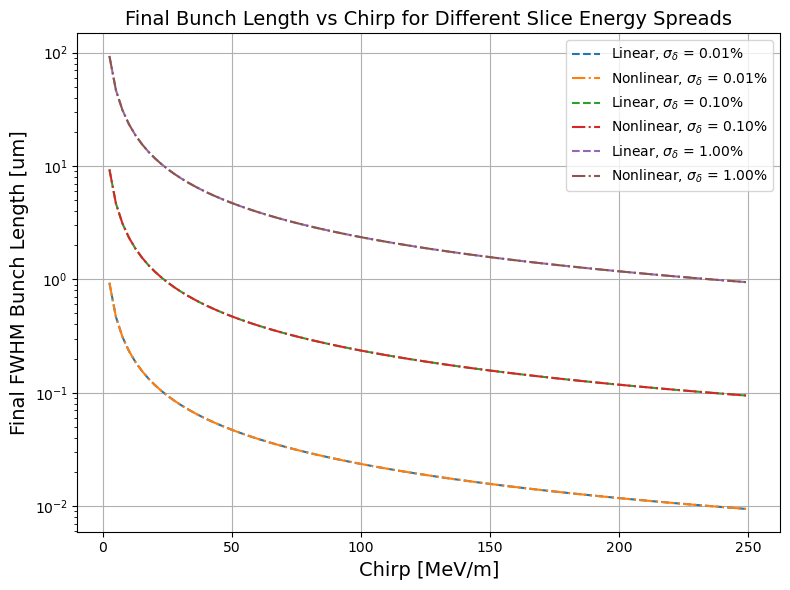

In [83]:
h = np.linspace(0, 250, 100)*1e6/(gamma*0.511) # chirp, m-1
sigma_delta = np.array([0.01, 0.1, 1.0])/100 #normalized slice energy spread
sigma_z0 = 10e-6 # [m], initial  bunch length


def sigma_z_linear(sigma_z0, sigma_delta, h):
    R_56 = -1/h 
    T_566 = -1.5*R_56 
    return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2)

def sigma_z_nonlinear(sigma_z0, sigma_delta, h):
    R_56 = -1/h 
    T_566 = -1.5*R_56 
    return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 - T_566**2*(sigma_delta**4))


plt.figure(figsize=(8,6))
for i in range(len(sigma_delta)):
    plt.semilogy(h*gamma*0.511/(1e6), 2.355*sigma_z_linear(sigma_z0, sigma_delta[i], h)*1e6, "--", label=f'Linear, $\\sigma_{{\\delta}}$ = {100*sigma_delta[i]:.2f}%')
    plt.semilogy(h*gamma*0.511/(1e6), 2.355*sigma_z_nonlinear(sigma_z0, sigma_delta[i], h)*1e6, "-.", label=f'Nonlinear, $\\sigma_{{\\delta}}$ = {100*sigma_delta[i]:.2f}%')
plt.xlabel('Chirp [MeV/m]', fontsize=14)
plt.ylabel('Final FWHM Bunch Length [um]', fontsize=14)
plt.title('Final Bunch Length vs Chirp for Different Slice Energy Spreads', fontsize=14)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:7: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:9: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2)
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2361415636.py:2: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2361415636.py:11: RuntimeWarning: invalid value encountered in multiply
  sigma_z2 = sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 + 2*T_522**2*sigma_xp**4 + 2*T_544**2*sigma_yp**4 - T_566**2*(sigma_delta**4) - 2*T_566*sigma_delta**2*(T_522*sigma_xp**2 + T_544*sigma_yp**2)


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:7: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3828793707.py:9: RuntimeWarning: invalid value encountered in multiply
  return np.sqrt(sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2)
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2361415636.py:2: RuntimeWarning: divide by zero encountered in divide
  R_56 = -1/h
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2361415636.py:11: RuntimeWarning: invalid value encountered in multiply
  sigma_z2 = sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 + 2*T_522**2*sigma_xp**4 + 2*T_544**2*sigma_yp**4 - T_566**2*(sigma_delta**4) - 2*T_566*sigma_delta**2*(T_522*sigma_xp**2 + T_544*sigma_yp**2)


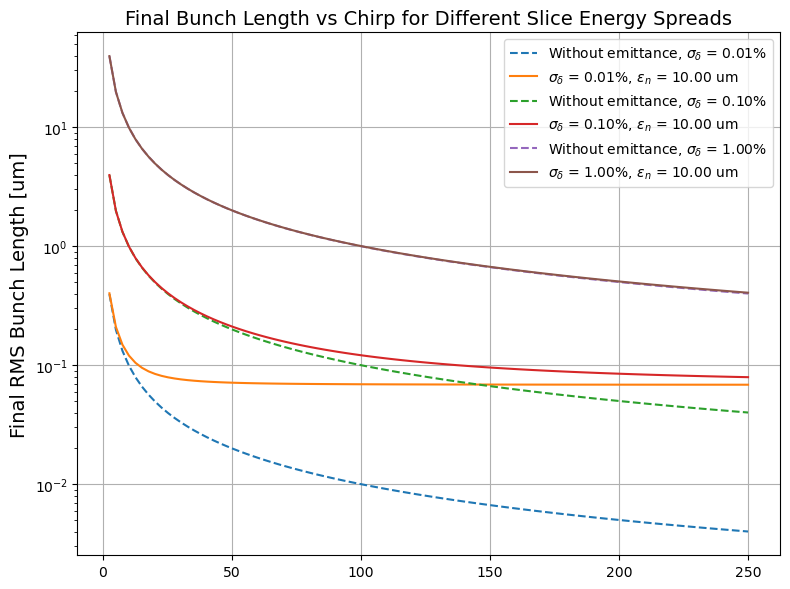

In [84]:
def sigma_z_emit(sigma_z0, sigma_delta, h, eps_n,T_522,T_544,sigma_x,sigma_y, gamma):
    R_56 = -1/h 
    T_566 = -1.5*R_56
    eps_g = eps_n/gamma # geometric emittance
    sigma_xp = eps_g/sigma_x # [rad], rms beam divergence
    sigma_yp = eps_g/sigma_y # [rad], rms beam divergence
    #delta_sigma_z = np.sqrt(3*T_522**2*sigma_xp**4 + 2*T_522*T_544*sigma_xp**2*sigma_yp**2 + 3*T_544**2*sigma_yp**4)
    delta_sigma_z = np.sqrt(2*T_522**2*sigma_xp**4 + 2*T_544**2*sigma_yp**4)


    sigma_z2 = sigma_z0**2*(1 + h*R_56)**2 + R_56**2*sigma_delta**2 + 2*T_522**2*sigma_xp**4 + 2*T_544**2*sigma_yp**4 - T_566**2*(sigma_delta**4) - 2*T_566*sigma_delta**2*(T_522*sigma_xp**2 + T_544*sigma_yp**2)


    return np.sqrt(sigma_z2)

eps_n = 10*1e-6 #normalized emittance (m)
sigma_x = 10e-6 # [m], rms beam size
sigma_y = 10e-6 # [m], rms beam size


plt.figure(figsize=(8,6))
for i in range(len(sigma_delta)):
    plt.semilogy(h*gamma*0.511/(1e6), sigma_z_linear(sigma_z0, sigma_delta[i], h)*1e6, "--", label=f'Without emittance, $\\sigma_{{\\delta}}$ = {100*sigma_delta[i]:.2f}%')
    plt.semilogy(h*gamma*0.511/(1e6), sigma_z_emit(sigma_z0, sigma_delta[i], h, eps_n, T_522, T_544, sigma_x, sigma_y, gamma)*1e6, "-", label=f'$\\sigma_{{\\delta}}$ = {100*sigma_delta[i]:.2f}%, $\\epsilon_n$ = {eps_n*1e6:.2f} um')
plt.ylabel('Final RMS Bunch Length [um]', fontsize=14)
plt.title('Final Bunch Length vs Chirp for Different Slice Energy Spreads', fontsize=14)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
z0 = 0 #m
beta = 0.1 #m
energy = 1e10 #eV
energy_spread = energy*1e-3
total_charge = 5e-10
gamma0 = energy/(m_e*c**2/e)
eps_n = 200e-6 #m
eps_g = eps_n / gamma0

sig_x = np.sqrt(beta*eps_g)
sig_y = np.sqrt(beta*eps_g)
sigma_tx = sig_x/beta
sigma_ty = sig_y/beta

sig_z = 10.0e-6

#n_emit_w = 10.0e-6

n_physical_particles = total_charge/e 
n_macroparticles = int(1e5)
w = e*np.ones(n_macroparticles)*n_physical_particles/n_macroparticles
id = np.arange(0, n_macroparticles, 1)


x = np.random.normal(loc = 0.0, scale = sig_x, size = n_macroparticles)
y = np.random.normal(loc = 0.0, scale = sig_y, size = n_macroparticles)
z = np.random.normal(loc = z0, scale = sig_z, size = n_macroparticles)

theta_x = np.random.normal(loc=0.0, scale = sigma_tx, size = n_macroparticles)
theta_y = np.random.normal(loc=0.0, scale = sigma_ty, size = n_macroparticles)

# Momentum in eV/c units (for ultra-relativistic particles, p ≈ E)

#chirp
h = 10*1e6*1e6 #eV/m

uz =  h*z + np.random.normal(loc=energy, scale = energy_spread, size = n_macroparticles)

ux = uz*np.tan(theta_x)
uy = uz*np.tan(theta_y)

t = z/c



data = {'x' : x, 
        'px' : ux,
        'y' : y,
        'py' : uy,
        'z' : z, 
        'pz' : uz, 
        't' : t,
        'weight' : w,
        'id' : id,
        'status' : 1,
        'species' : 'electron'}

P0 = ParticleGroup(data = data )

Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


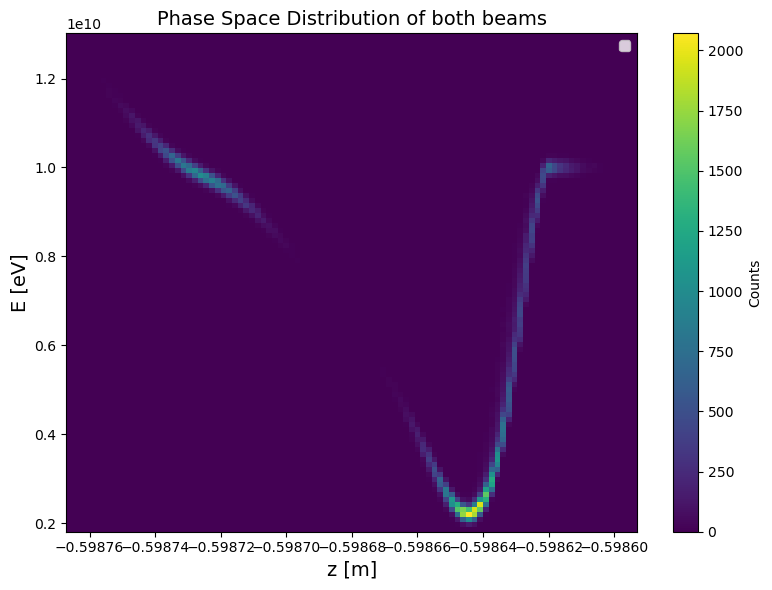

Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


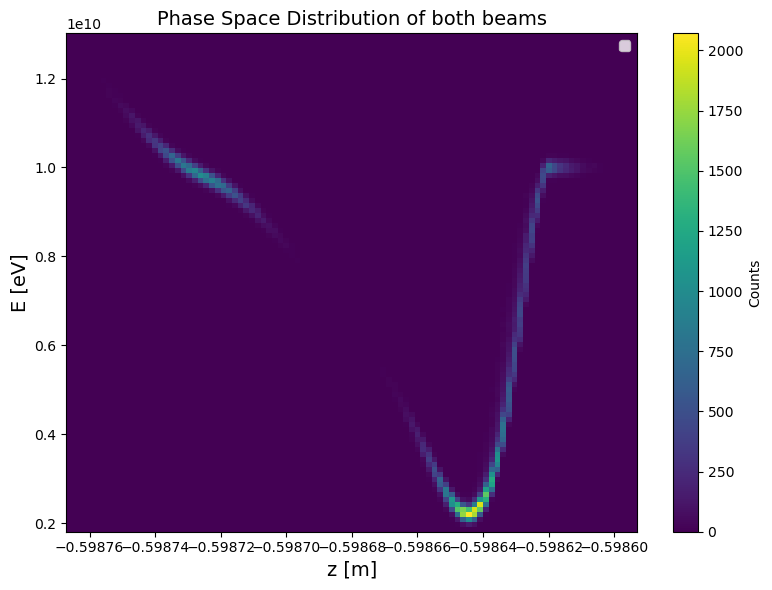

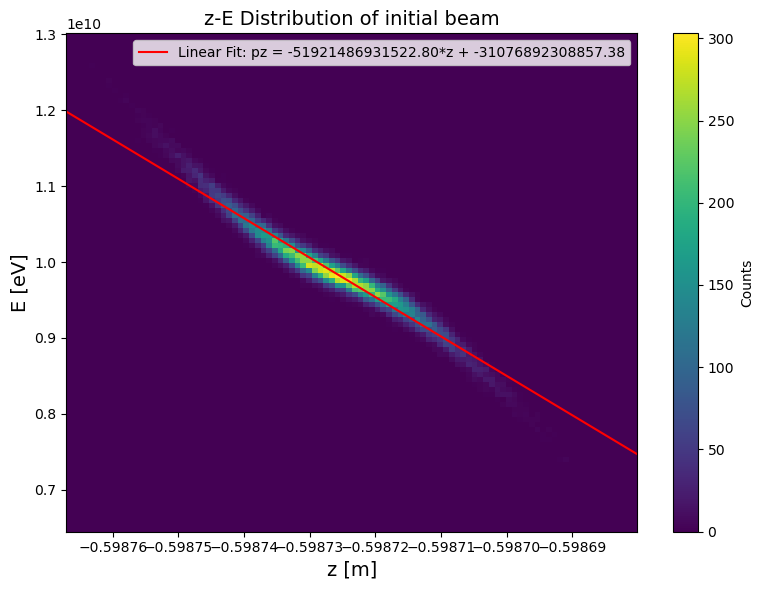

Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


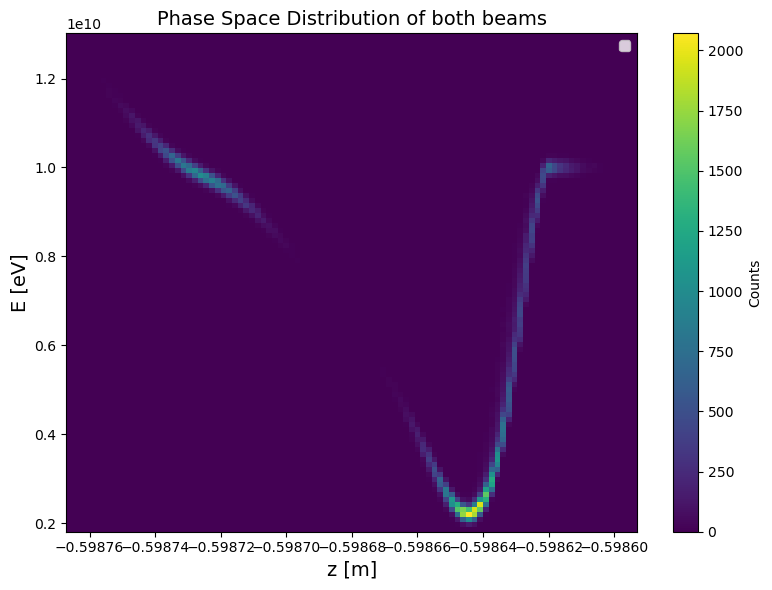

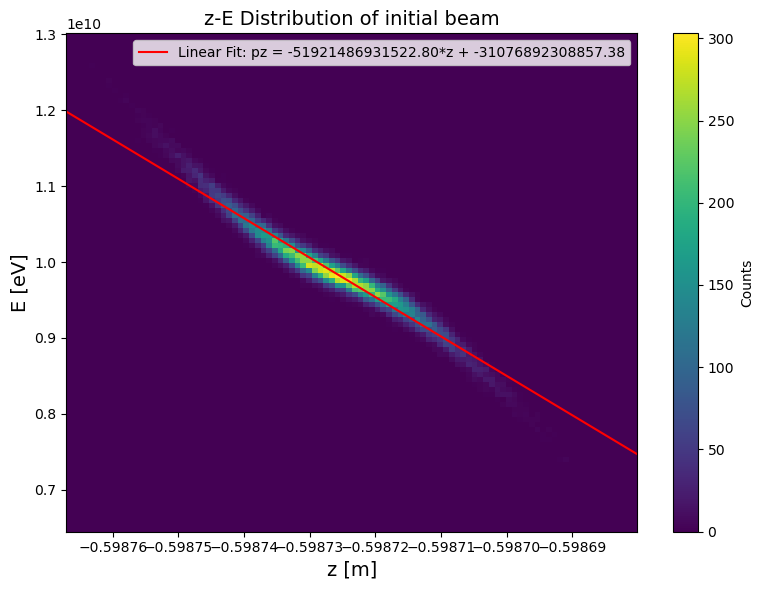

Chirp of initial beam: 51.92 MeV/um


Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


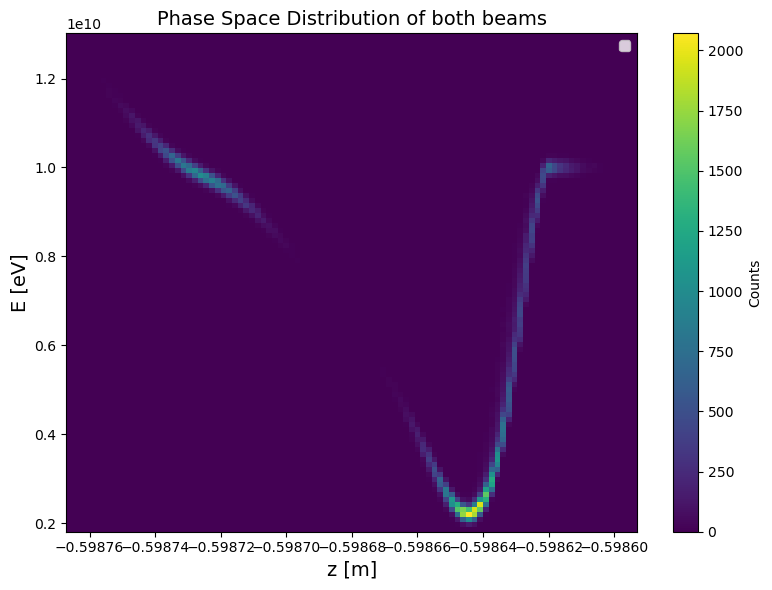

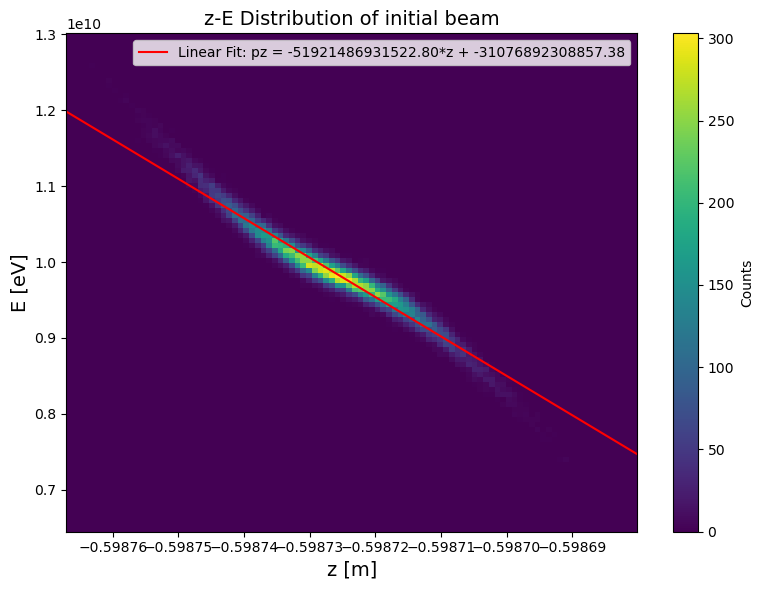

Chirp of initial beam: 51.92 MeV/um


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


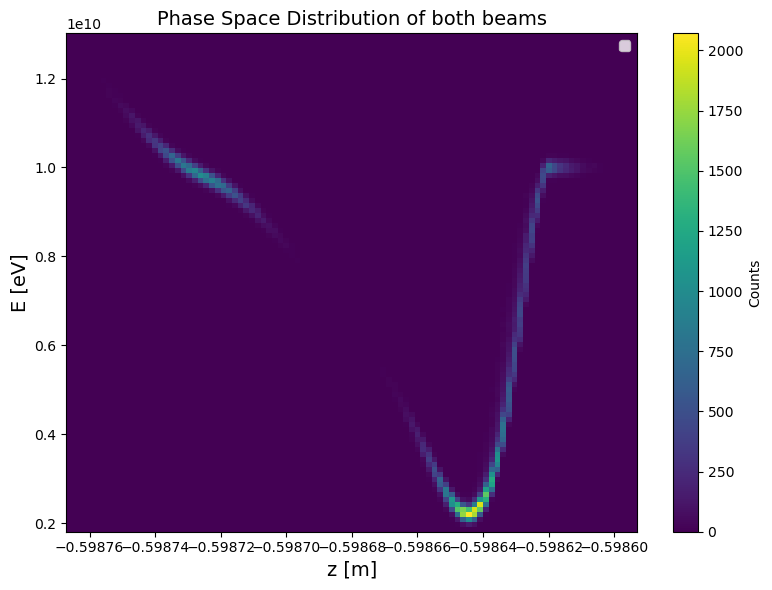

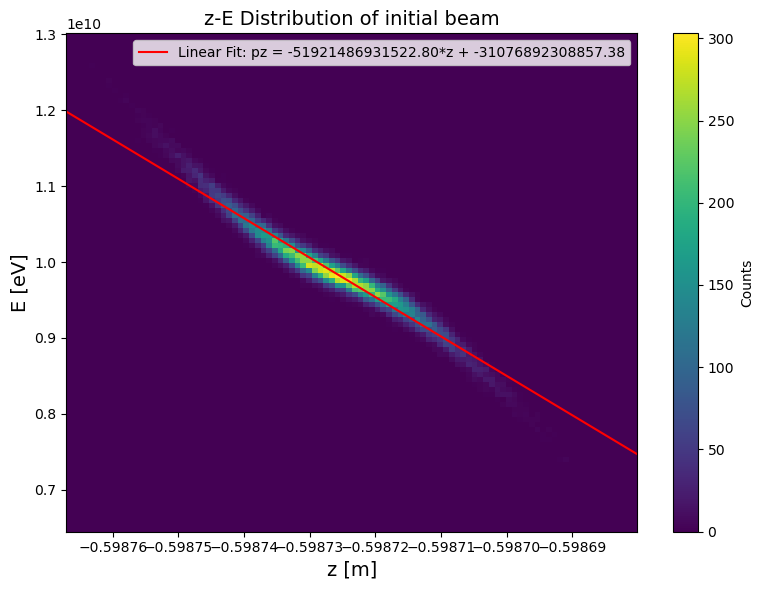

Chirp of initial beam: 51.92 MeV/um


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


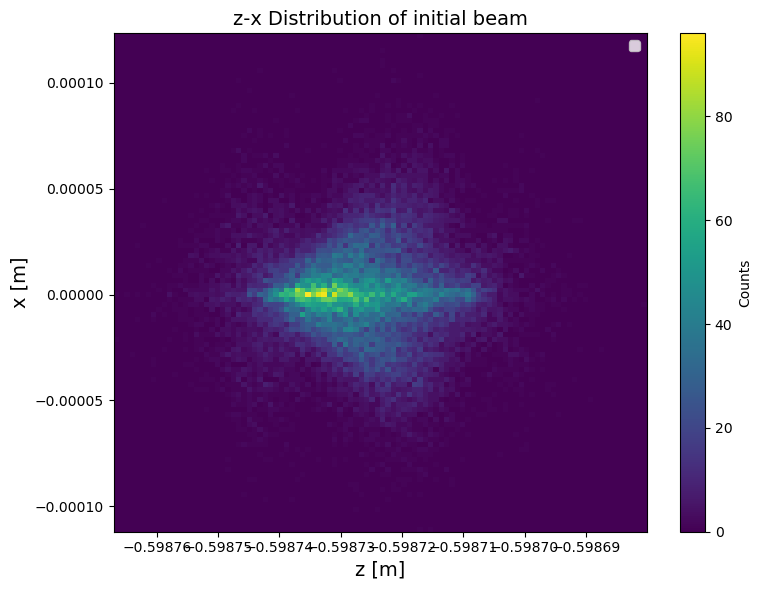

Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


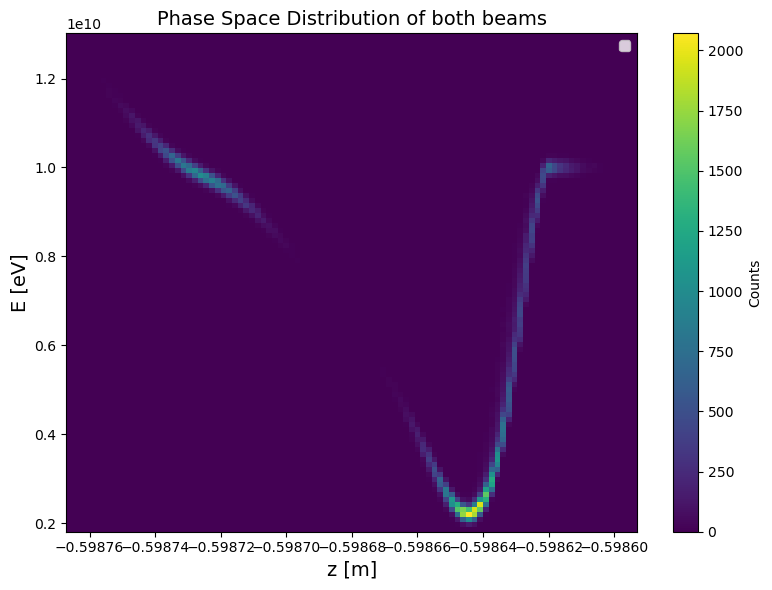

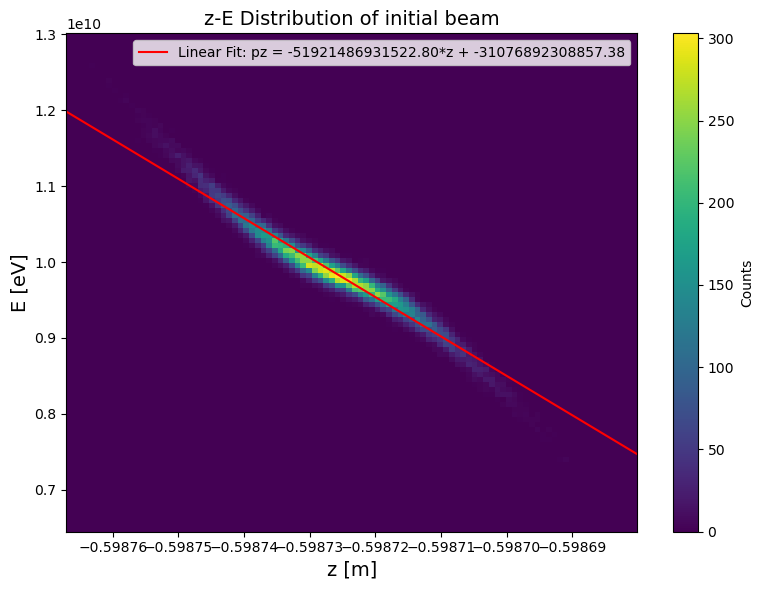

Chirp of initial beam: 51.92 MeV/um


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


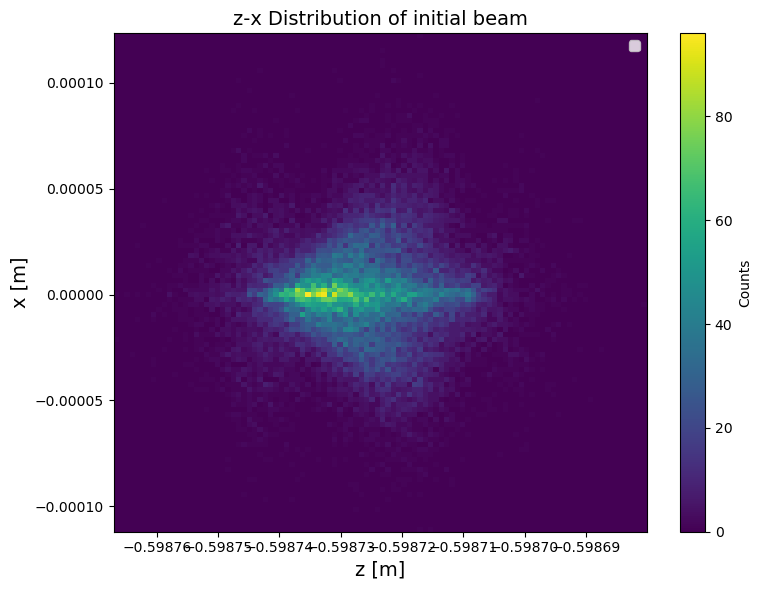

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Witness beam Twiss parameters
X-plane: eps_g = 4.619080e-09 m·rad, eps_n = 8.929486e-05 m·rad, beta = 1.158214e-01 m, alpha = -1.967974e+00, gamma = 4.207273e+01 1/m
Y-plane: eps_g = 4.639224e-09 m·rad, eps_n = 8.968429e-05 m·rad, beta = 1.152870e-01 m, alpha = -1.967408e+00, gamma = 4.224842e+01 1/m


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


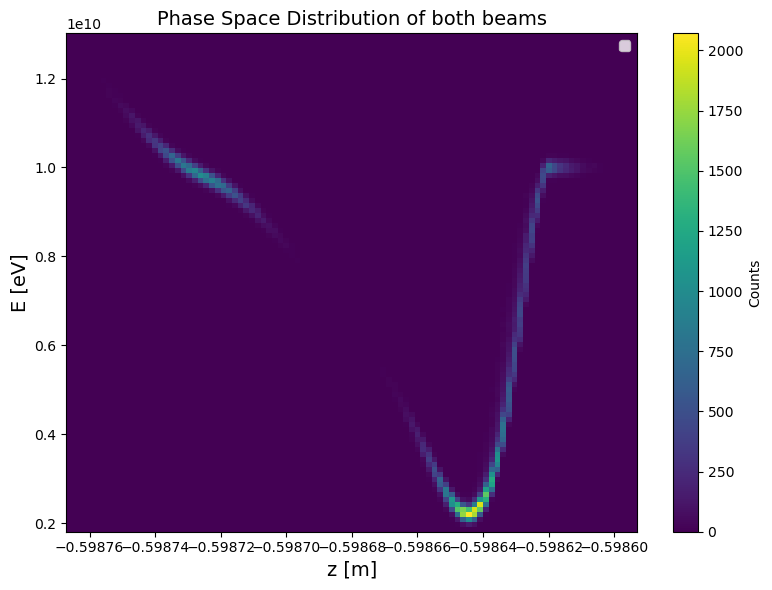

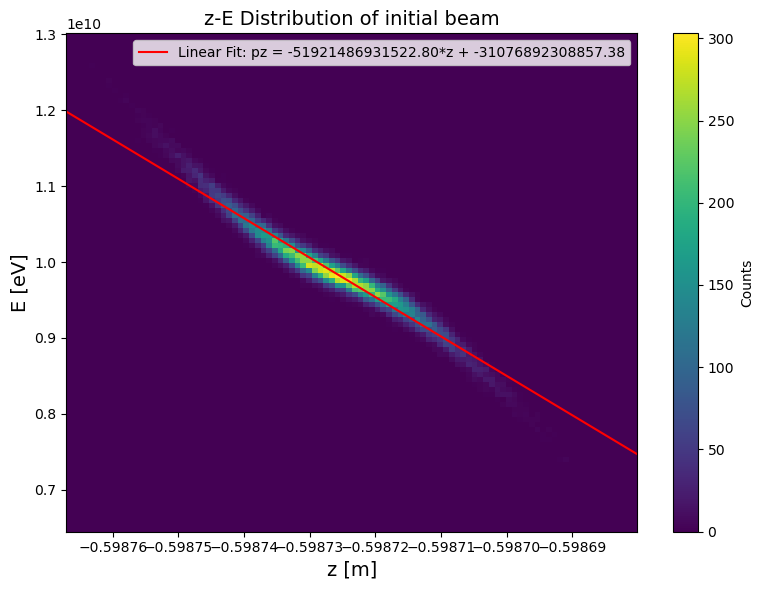

Chirp of initial beam: 51.92 MeV/um


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


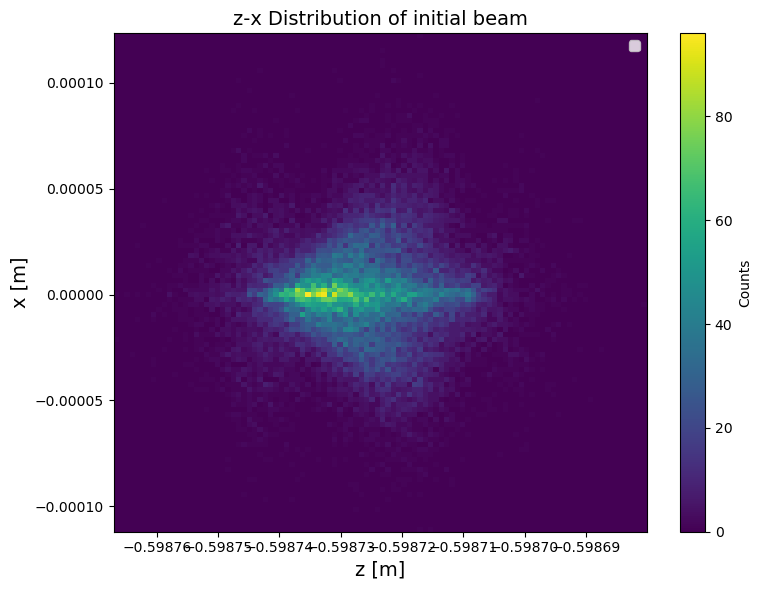

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/3134581711.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


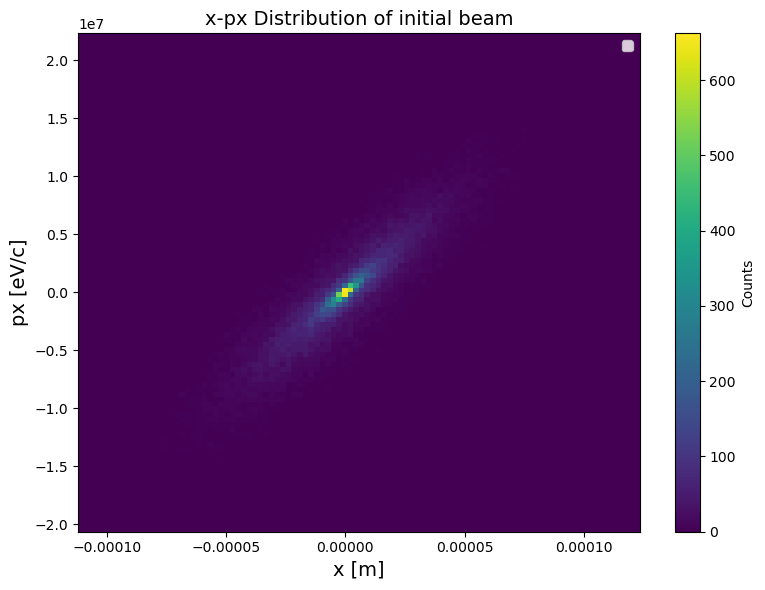

In [ ]:
plasma_beam = ParticleGroup(h5 = "/Users/upx/FACET2-S2E/examples/end_beam.h5")


def twiss_from_distribution(u, up, w=None):
    if w is None:
        m_u2 = np.mean(u * u)
        m_uup = np.mean(u * up)
        m_up2 = np.mean(up * up)
    else:
        sw = np.sum(w)
        m_u2 = np.sum(w * u * u) / sw
        m_uup = np.sum(w * u * up) / sw
        m_up2 = np.sum(w * up * up) / sw

    emit = np.sqrt(max(m_u2 * m_up2 - m_uup**2, 0.0))
    beta = m_u2 / emit
    alpha = -m_uup / emit
    gamma_twiss = m_up2 / emit
    return emit, beta, alpha, gamma_twiss

#plasma_beam = P0
z_plasma = -plasma_beam.t*c #m
pz_plasma = plasma_beam.pz #eV/c
z_center = (np.max(z_plasma) + np.min(z_plasma))/2
plasma_beam_witness = plasma_beam[z_plasma < z_center]
#plasma_beam_witness = plasma_beam
z_plasma_witness = -plasma_beam_witness.t*c
pz_plasma_witness = plasma_beam_witness.pz
x_plasma_witness = plasma_beam_witness.x
px_plasma_witness = plasma_beam_witness.px
a, b = np.polyfit(z_plasma_witness, pz_plasma_witness, 1)

xp_witness = plasma_beam_witness.px / plasma_beam_witness.pz
yp_witness = plasma_beam_witness.py / plasma_beam_witness.pz
w_witness = plasma_beam_witness.weight

emit_x_w, beta_x_w, alpha_x_w, gamma_x_w = twiss_from_distribution(
    plasma_beam_witness.x, xp_witness, w_witness
)
emit_y_w, beta_y_w, alpha_y_w, gamma_y_w = twiss_from_distribution(
    plasma_beam_witness.y, yp_witness, w_witness
)

gamma_rel_w = np.mean(plasma_beam_witness.gamma)

print("Witness beam Twiss parameters")
print(f"X-plane: eps_g = {emit_x_w:.6e} m·rad, eps_n = {emit_x_w*gamma_rel_w:.6e} m·rad, "
      f"beta = {beta_x_w:.6e} m, alpha = {alpha_x_w:.6e}, gamma = {gamma_x_w:.6e} 1/m")
print(f"Y-plane: eps_g = {emit_y_w:.6e} m·rad, eps_n = {emit_y_w*gamma_rel_w:.6e} m·rad, "
      f"beta = {beta_y_w:.6e} m, alpha = {alpha_y_w:.6e}, gamma = {gamma_y_w:.6e} 1/m")



z_plot = np.linspace(np.min(z_plasma_witness), np.max(z_plasma_witness), 100)
plt.figure(figsize=(8,6))
plt.hist2d(z_plasma, pz_plasma, bins=100, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('E [eV]', fontsize=14)
#plt.xlim(z_center, np.max(z_plasma))
plt.title('Phase Space Distribution of both beams', fontsize=14)
plt.colorbar(label='Counts')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.hist2d(z_plasma_witness, pz_plasma_witness, bins=100, cmap='viridis')
plt.plot(z_plot, a*z_plot + b, color='red', label=f'Linear Fit: pz = {a:.2f}*z + {b:.2f}')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('E [eV]', fontsize=14)
#plt.xlim(z_center, np.max(z_plasma))
plt.title('z-E Distribution of initial beam', fontsize=14)
plt.colorbar(label='Counts')
plt.legend()
plt.tight_layout()
plt.show()
h = a # chirp, eV/m
print(f"Chirp of initial beam: {np.abs(h)*1e-12:.2f} MeV/um")

plt.figure(figsize=(8,6))
plt.hist2d(z_plasma_witness, x_plasma_witness, bins=100, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('x [m]', fontsize=14)
#plt.xlim(z_center, np.max(z_plasma))
plt.title('z-x Distribution of initial beam', fontsize=14)
plt.colorbar(label='Counts')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.hist2d(x_plasma_witness, px_plasma_witness, bins=100, cmap='viridis')
plt.xlabel('x [m]', fontsize=14)
plt.ylabel('px [eV/c]', fontsize=14)
#plt.xlim(z_center, np.max(z_plasma))
plt.title('x-px Distribution of initial beam', fontsize=14)
plt.colorbar(label='Counts')
plt.legend()
plt.tight_layout()
plt.show()

R_56 = 0.000190 m


R_56 = 0.000190 m


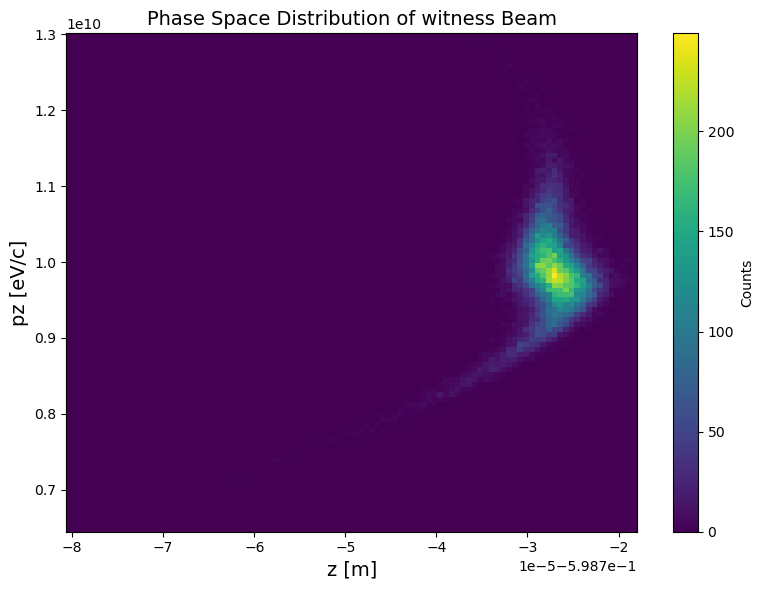

R_56 = 0.000190 m


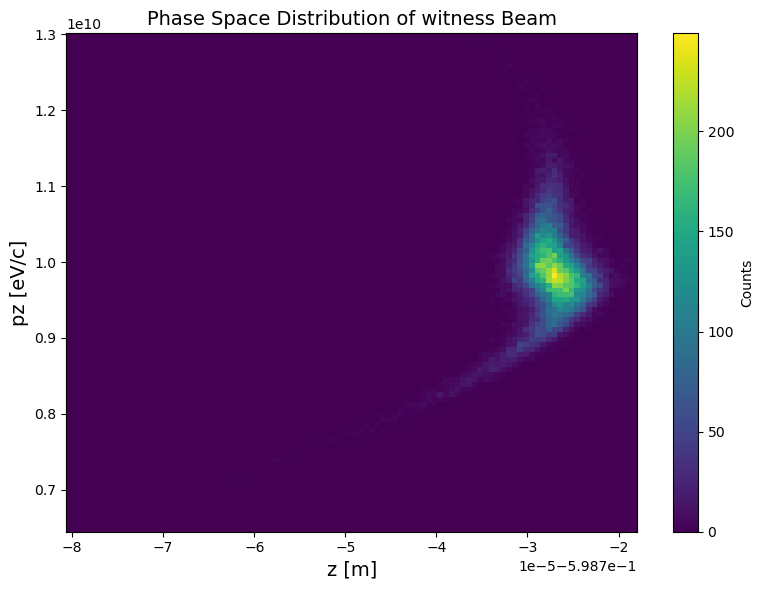

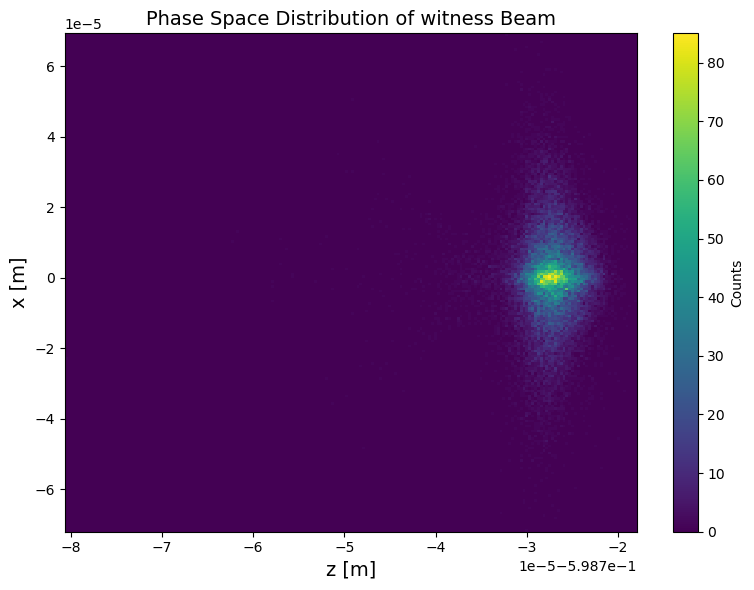

R_56 = 0.000190 m


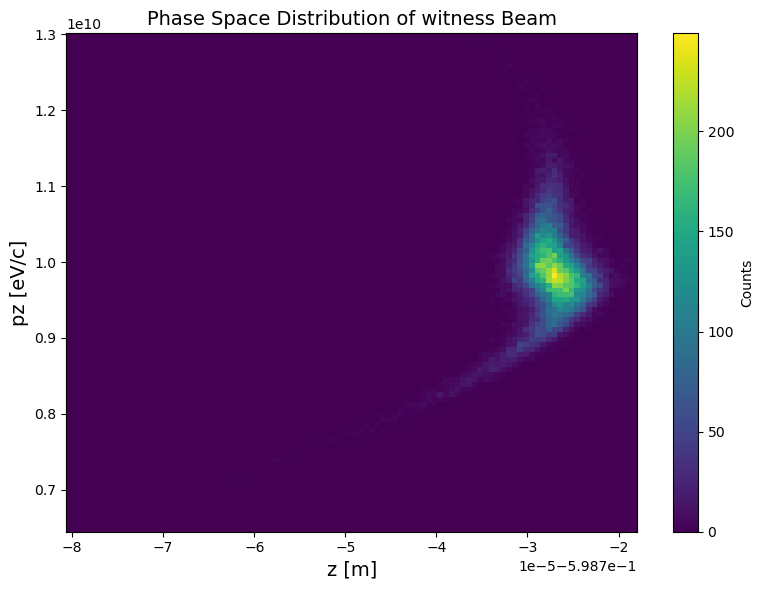

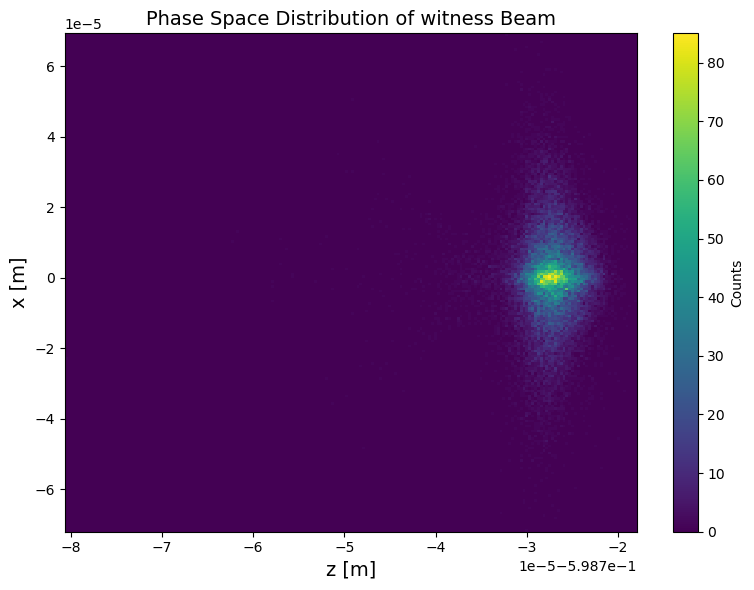

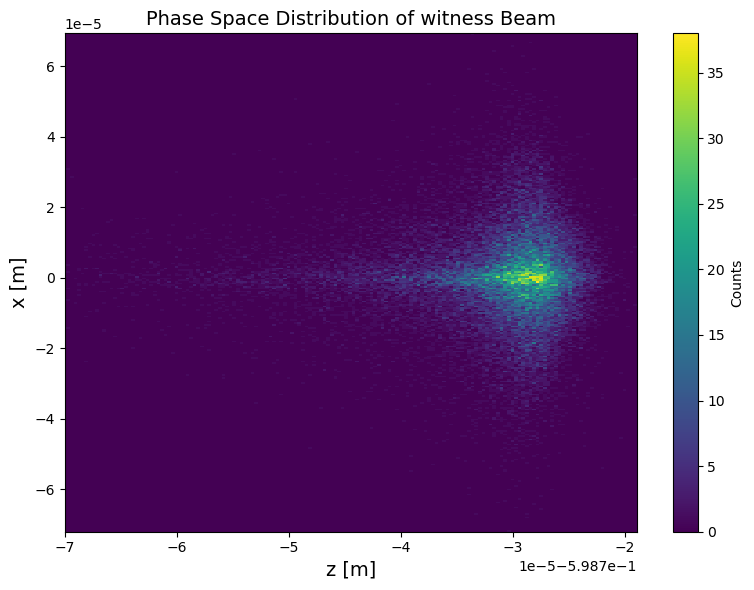

R_56 = 0.000190 m


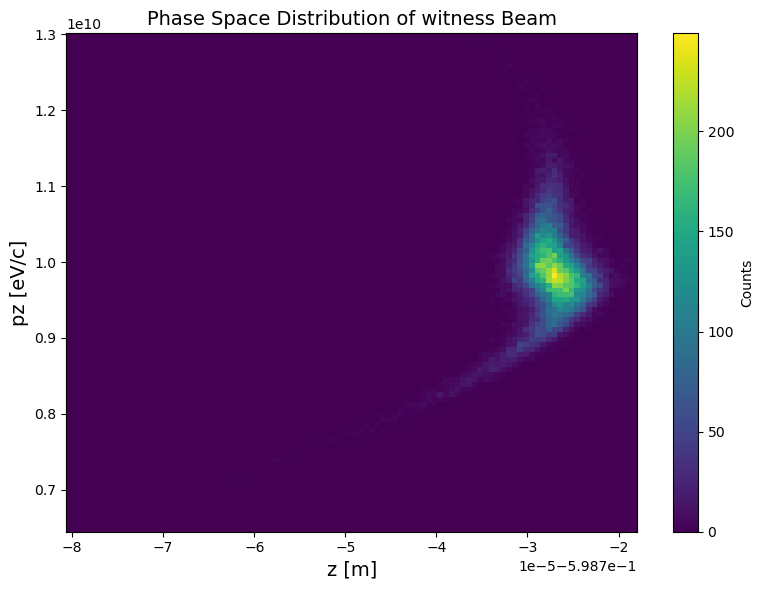

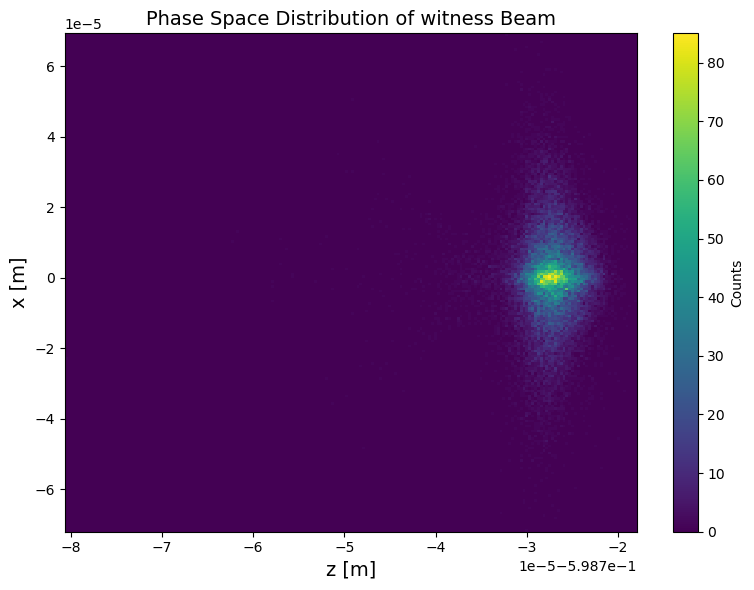

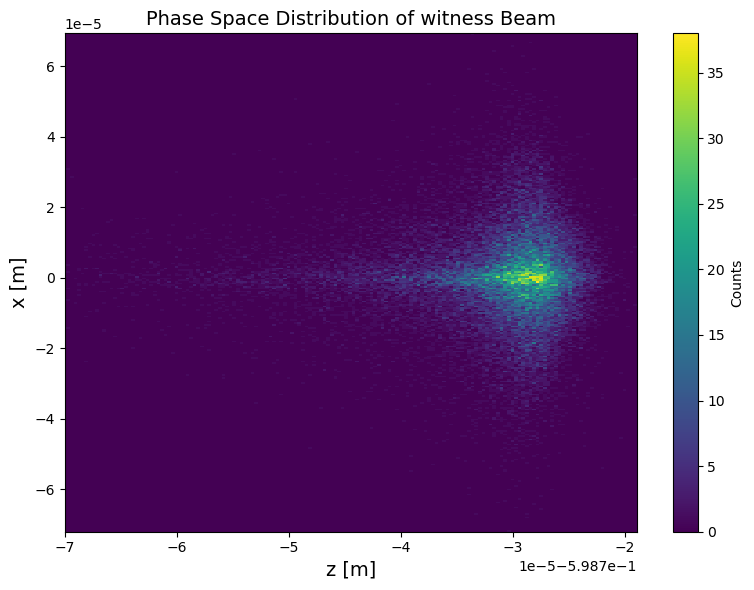

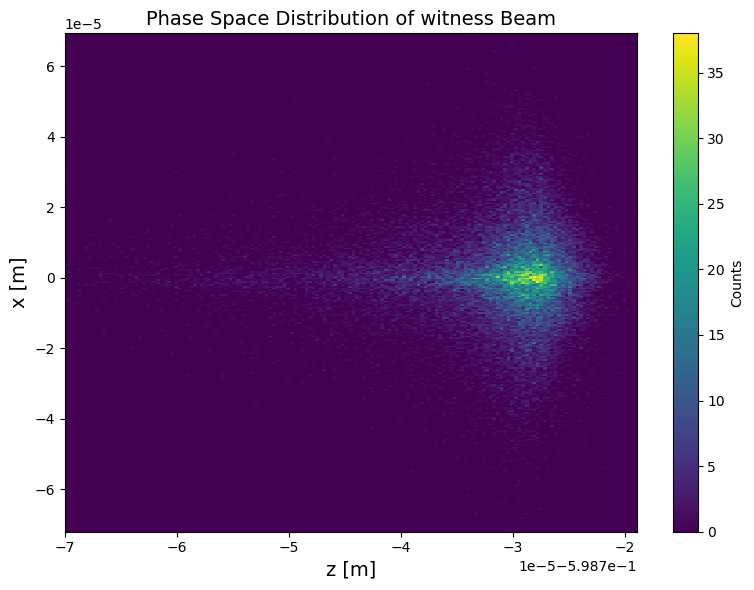

Initial bunch length (sigma_z_witness): 10.020 um
Final bunch length (sigma_z): 2.722 um
Final bunch length with divergence (sigma_z_with_div): 7.064 um
Final bunch length with divergence and transverse (sigma_z_div_and_trans): 7.066 um


In [ ]:
E0 = np.mean(plasma_beam_witness.pz)
gamma = np.mean(plasma_beam_witness.gamma)
delta = (plasma_beam_witness.pz - E0)/E0
xp = plasma_beam_witness.px/plasma_beam_witness.pz
yp = plasma_beam_witness.py/plasma_beam_witness.pz
x = plasma_beam_witness.x
y = plasma_beam_witness.y
transverse_phase_space = M4 @ np.array([x, xp, y, yp])

h_norm = h/E0
R_56 = -1/h_norm
print(f"R_56 = {R_56:.6f} m")
T_566 = -1.5*R_56
z = z_plasma_witness + R_56*delta + T_566*delta**2 

z_with_div = z_plasma_witness + R_56*delta + T_566*delta**2 + T_522*xp**2 + T_544*yp**2

z_div_and_trans = z_plasma_witness + R_56*delta + T_566*delta**2 + T_522*xp**2 + T_544*yp**2 + T_511*x**2 + T_533*y**2

sigma_z_witness = np.std(z_plasma_witness)
sigma_z = np.std(z)
sigma_z_with_div = np.std(z_with_div)
sigma_z_div_and_trans = np.std(z_div_and_trans)
transported_data = {
    'x': transverse_phase_space[0],
    'px': transverse_phase_space[1]*plasma_beam_witness.pz,
    'y': transverse_phase_space[2],
    'py': transverse_phase_space[3]*plasma_beam_witness.pz,
    'z': z,
    'pz': plasma_beam_witness.pz,
    't': plasma_beam_witness.t,
    'weight': plasma_beam_witness.weight,
    'id': plasma_beam_witness.id,
    'status': plasma_beam_witness.status,
    'species': 'electron',
}

transported_beam = ParticleGroup(data=transported_data)
z_transported = transported_beam.z
pz_transported = transported_beam.pz
z_center = (np.max(z_transported) + np.min(z_transported))/2

x_transported = transported_beam.x 
y_transported = transported_beam.y


plt.figure(figsize=(8,6))
plt.hist2d(z_transported, pz_transported, bins=100, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('pz [eV/c]', fontsize=14)
plt.title('Phase Space Distribution of witness Beam', fontsize=14)
plt.colorbar(label='Counts')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.hist2d(z_transported, x_transported, bins=200, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('x [m]', fontsize=14)
plt.title('Phase Space Distribution of witness Beam', fontsize=14)
plt.colorbar(label='Counts')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.hist2d(z_with_div, x_transported, bins=300, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('x [m]', fontsize=14)
plt.xlim(-0.59877, np.max(z_with_div))
plt.title('Phase Space Distribution of witness Beam', fontsize=14)
plt.colorbar(label='Counts')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.hist2d(z_div_and_trans, x_transported, bins=300, cmap='viridis')
plt.xlabel('z [m]', fontsize=14)
plt.ylabel('x [m]', fontsize=14)
plt.xlim(-0.59877, np.max(z_div_and_trans))
plt.title('Phase Space Distribution of witness Beam', fontsize=14)
plt.colorbar(label='Counts')

plt.tight_layout()
plt.show()
print(f"Initial bunch length (sigma_z_witness): {sigma_z_witness*1e6:.3f} um")
print(f"Final bunch length (sigma_z): {sigma_z*1e6:.3f} um")
print(f"Final bunch length with divergence (sigma_z_with_div): {sigma_z_with_div*1e6:.3f} um")
print(f"Final bunch length with divergence and transverse (sigma_z_div_and_trans): {sigma_z_div_and_trans*1e6:.3f} um")

xp_transported = transported_beam.px / transported_beam.pz
yp_transported = transported_beam.py / transported_beam.pz
w_transported = transported_beam.weight
gamma_rel_transported = np.mean(transported_beam.gamma)

emit_x_t, beta_x_t, alpha_x_t, gamma_x_t = twiss_from_distribution(
    transported_beam.x, xp_transported, w_transported
)
emit_y_t, beta_y_t, alpha_y_t, gamma_y_t = twiss_from_distribution(
    transported_beam.y, yp_transported, w_transported
)

print("Transported beam Twiss parameters")
print(f"X-plane: eps_g = {emit_x_t:.6e} m·rad, eps_n = {emit_x_t*gamma_rel_transported:.6e} m·rad, "
      f"beta = {beta_x_t:.6e} m, alpha = {alpha_x_t:.6e}, gamma = {gamma_x_t:.6e} 1/m")
print(f"Y-plane: eps_g = {emit_y_t:.6e} m·rad, eps_n = {emit_y_t*gamma_rel_transported:.6e} m·rad, "
      f"beta = {beta_y_t:.6e} m, alpha = {alpha_y_t:.6e}, gamma = {gamma_y_t:.6e} 1/m")

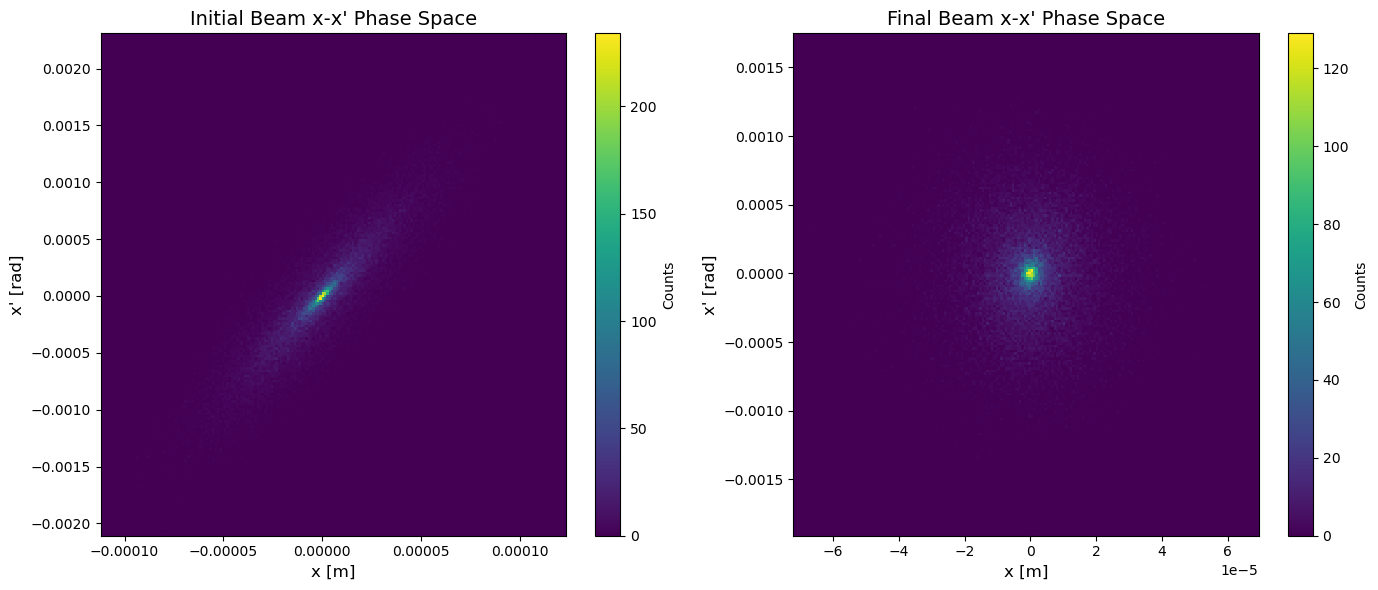

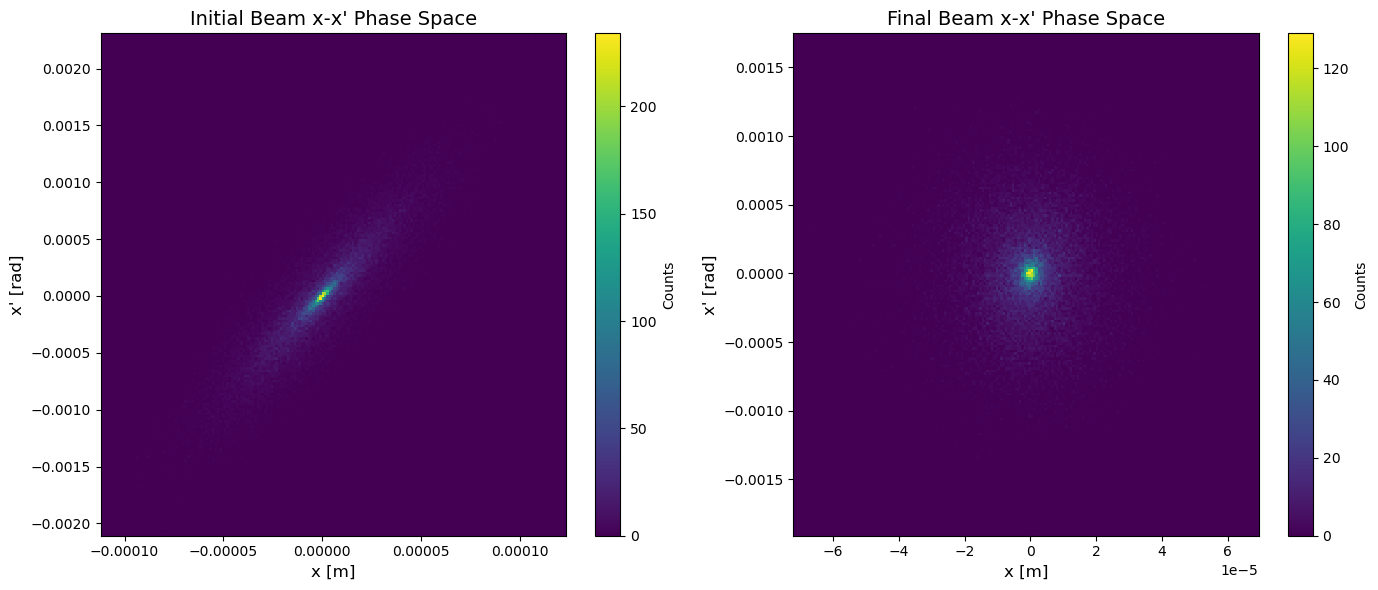

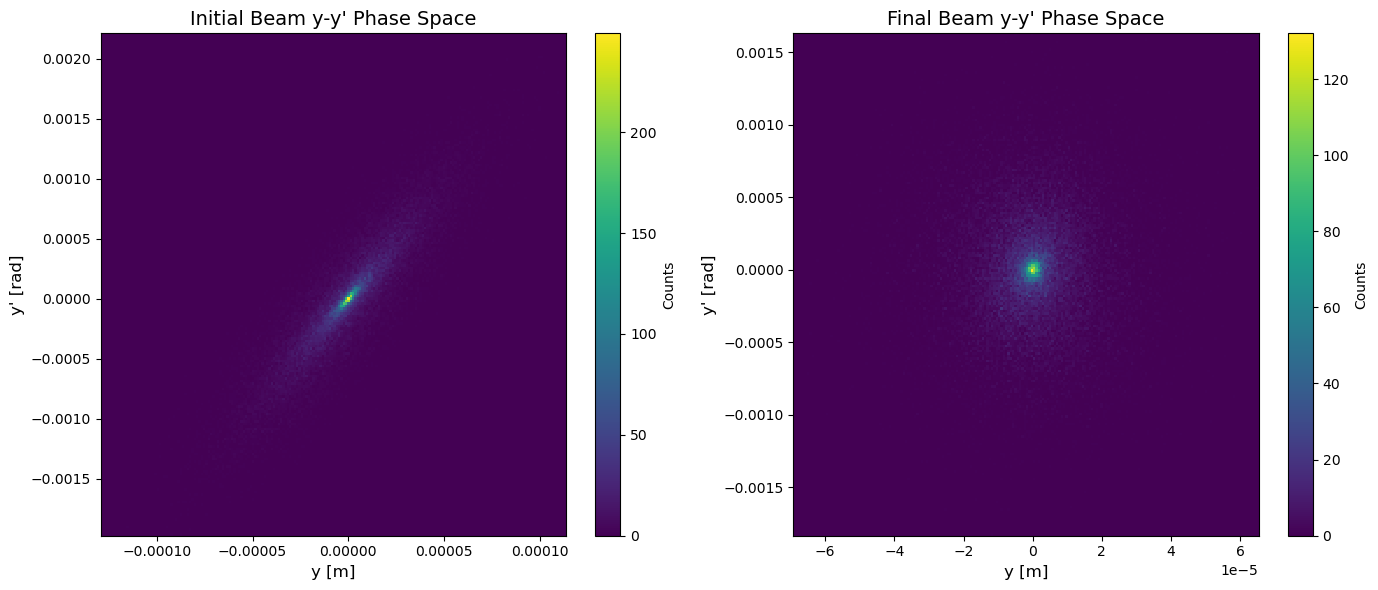

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Initial beam x-px phase space
axes[0].hist2d(x_plasma_witness, px_plasma_witness/plasma_beam_witness.pz, bins=200, cmap='viridis')
axes[0].set_xlabel('x [m]', fontsize=12)
axes[0].set_ylabel("x' [rad]", fontsize=12)
axes[0].set_title('Initial Beam x-x\' Phase Space', fontsize=14)
plt.colorbar(axes[0].collections[0], ax=axes[0], label='Counts')

# Final beam x-x' phase space
axes[1].hist2d(x_transported, transverse_phase_space[1], bins=200, cmap='viridis')
axes[1].set_xlabel('x [m]', fontsize=12)
axes[1].set_ylabel("x' [rad]", fontsize=12)
axes[1].set_title("Final Beam x-x' Phase Space", fontsize=14)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()

fig, axes_yy = plt.subplots(1, 2, figsize=(14, 6))

# Initial beam y-y' phase space
axes_yy[0].hist2d(
    plasma_beam_witness.y,
    plasma_beam_witness.py / plasma_beam_witness.pz,
    bins=200,
    cmap='viridis'
)
axes_yy[0].set_xlabel('y [m]', fontsize=12)
axes_yy[0].set_ylabel("y' [rad]", fontsize=12)
axes_yy[0].set_title("Initial Beam y-y' Phase Space", fontsize=14)
plt.colorbar(axes_yy[0].collections[0], ax=axes_yy[0], label='Counts')

# Final beam y-y' phase space
axes_yy[1].hist2d(
    y_transported,
    transverse_phase_space[3],
    bins=200,
    cmap='viridis'
)
axes_yy[1].set_xlabel('y [m]', fontsize=12)
axes_yy[1].set_ylabel("y' [rad]", fontsize=12)
axes_yy[1].set_title("Final Beam y-y' Phase Space", fontsize=14)
plt.colorbar(axes_yy[1].collections[0], ax=axes_yy[1], label='Counts')

plt.tight_layout()
plt.show()

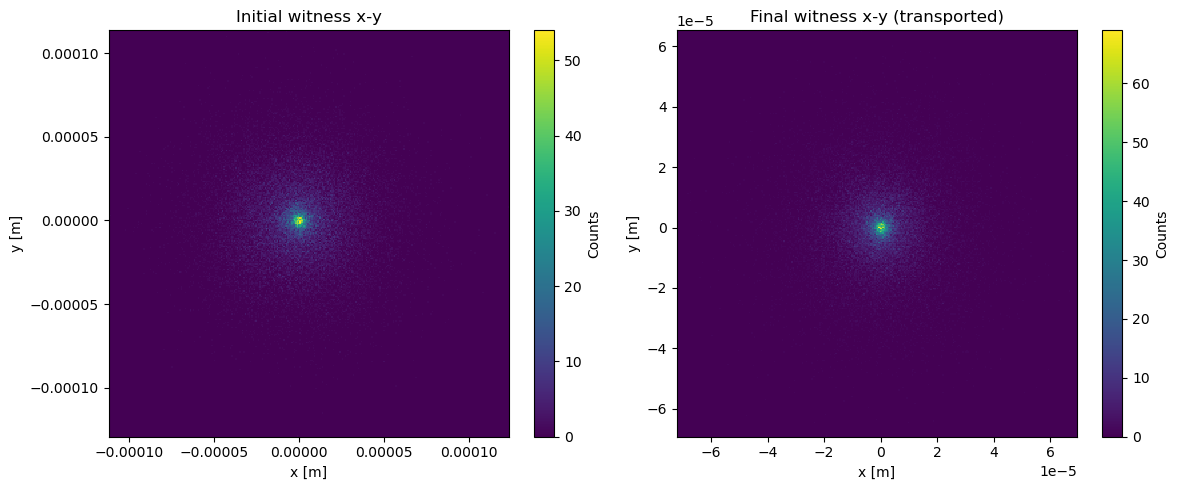

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# compute common axis limits with small padding
x_all = np.hstack([plasma_beam_witness.x, x_transported])
y_all = np.hstack([plasma_beam_witness.y, y_transported])
pad_x = 0.05 * (x_all.max() - x_all.min())
pad_y = 0.05 * (y_all.max() - y_all.min())
xlim = (x_all.min() - pad_x, x_all.max() + pad_x)
ylim = (y_all.min() - pad_y, y_all.max() + pad_y)

im0 = axes[0].hist2d(plasma_beam_witness.x, plasma_beam_witness.y, bins=300, cmap='viridis')
axes[0].set_title('Initial witness x-y')
axes[0].set_xlabel('x [m]')
axes[0].set_ylabel('y [m]')
plt.colorbar(im0[3], ax=axes[0], label='Counts')

im1 = axes[1].hist2d(x_transported, y_transported, bins=300, cmap='viridis')
axes[1].set_title('Final witness x-y (transported)')
axes[1].set_xlabel('x [m]')
axes[1].set_ylabel('y [m]')
plt.colorbar(im1[3], ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()



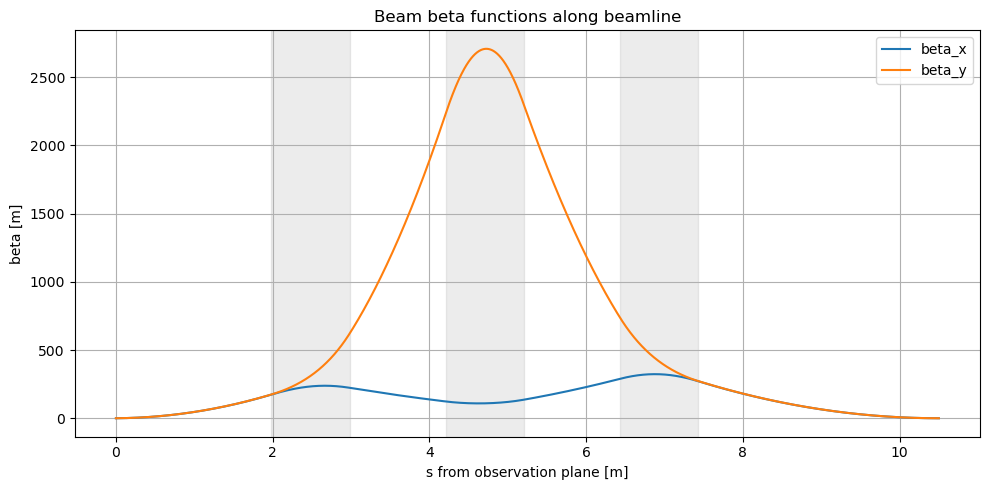

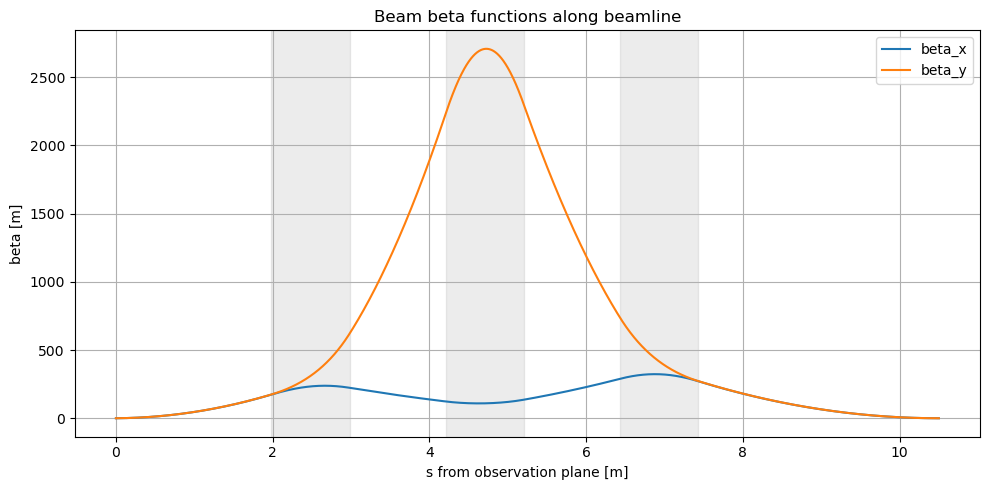

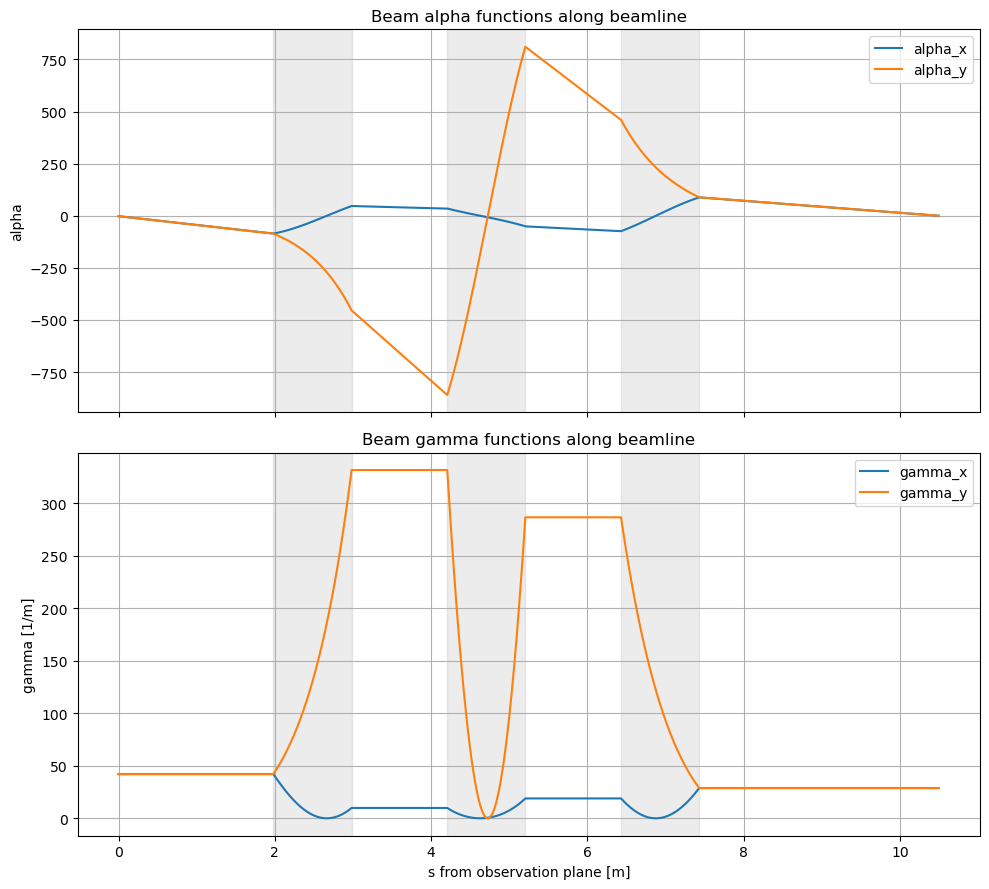

In [90]:
# Compute and plot Twiss evolution (beta, alpha, gamma) along the beamline.
#

# This cell does the following:
# 1) Builds initial second-moment (covariance) matrices from witness particles.
# 2) Converts those moments to Twiss parameters through emittance normalization.
# 3) Propagates the covariance through drift and quadrupole elements.
# 4) Samples and stores Twiss values along s (longitudinal position).
# 5) Plots beta, alpha, and gamma with quadrupole regions shaded.

# -----------------------------------------------------------------------------
# 1) INPUT DATA FROM THE WITNESS BEAM
# -----------------------------------------------------------------------------
w = plasma_beam_witness.weight  # Particle weights for weighted moments.

def moments(x, xp, w=None):
    # Return second-order moments for covariance construction.
    #
    # For one transverse plane, with coordinates (x, x'), the key moments are:
    #   <x^2>, <x x'>, <x'^2>
    # which form the 2x2 covariance-like matrix
    #   Sigma = [[<x^2>, <x x'>],
    #            [<x x'>, <x'^2>]]
    #
    # If weights are provided, compute weighted averages; otherwise unweighted.
    if w is None:
        m_x2 = np.mean(x * x)
        m_xxp = np.mean(x * xp)
        m_xp2 = np.mean(xp * xp)
    else:
        sw = np.sum(w)
        m_x2 = np.sum(w * (x * x)) / sw
        m_xxp = np.sum(w * (x * xp)) / sw
        m_xp2 = np.sum(w * (xp * xp)) / sw
    return m_x2, m_xxp, m_xp2

# Build normalized transverse coordinates for the witness beam.
# x' and y' are taken as p_x/p_z and p_y/p_z (small-angle approximation).
x0 = plasma_beam_witness.x
xp0 = plasma_beam_witness.px / plasma_beam_witness.pz
y0 = plasma_beam_witness.y
yp0 = plasma_beam_witness.py / plasma_beam_witness.pz

# Compute weighted second moments in both planes.
m_x2, m_xxp, m_xp2 = moments(x0, xp0, w)
m_y2, m_yyp, m_yp2 = moments(y0, yp0, w)

# -----------------------------------------------------------------------------
# 2) EMITTANCE AND INITIAL SIGMA MATRICES
# -----------------------------------------------------------------------------
# Geometric emittance in each plane from determinant:
#   epsilon = sqrt(<x^2><x'^2> - <x x'>^2)
emit_x = np.sqrt(max(m_x2 * m_xp2 - m_xxp**2, 0.0))
emit_y = np.sqrt(max(m_y2 * m_yp2 - m_yyp**2, 0.0))
if emit_x == 0 or emit_y == 0:
    raise RuntimeError("Zero emittance from moments")

# Initial second-moment matrices at the observation plane.
# These are propagated through each lattice element via:
#   Sigma_out = M Sigma_in M^T
sig_x = np.array([[m_x2, m_xxp], [m_xxp, m_xp2]])
sig_y = np.array([[m_y2, m_yyp], [m_yyp, m_yp2]])

# -----------------------------------------------------------------------------
# 3) LATTICE MODEL AND SAMPLING CONTROL
# -----------------------------------------------------------------------------
# Lattice sequence from observation plane to image plane.
# Tuple format: (element_type, length, quadrupole_index_if_needed).
seq = [
    ('drift', d1, None),
    ('quad', LEFF_QS1, 0),
    ('drift', d2, None),
    ('quad', LEFF_QS2, 1),
    ('drift', d3, None),
    ('quad', LEFF_QS3, 2),
    ('drift', d4, None),
]

# Number of sampling points per element type.
# Larger numbers make smoother curves at higher cost.
pts_drift = 200
pts_quad = 200

# Containers for sampled longitudinal positions and Twiss values.
s_vals = []
beta_x_vals = []
beta_y_vals = []
alpha_x_vals = []
alpha_y_vals = []
gamma_x_vals = []
gamma_y_vals = []

# Running longitudinal position from observation plane.
s_cur = 0.0

def propagate_with_M(sig, M):
    # Linear transport of second moments through transfer matrix M.
    return M @ sig @ M.T

def record_twiss(sig_x_loc, sig_y_loc, s_loc):
    # Convert local sigma matrices to Twiss parameters and store them.
    #
    # Using standard definitions with geometric emittance epsilon:
    #   beta  = Sigma_11 / epsilon
    #   alpha = -Sigma_12 / epsilon
    #   gamma = Sigma_22 / epsilon
    # (gamma_twiss, not relativistic gamma)
    s_vals.append(s_loc)
    beta_x_vals.append(sig_x_loc[0, 0] / emit_x)
    alpha_x_vals.append(-sig_x_loc[0, 1] / emit_x)
    gamma_x_vals.append(sig_x_loc[1, 1] / emit_x)
    beta_y_vals.append(sig_y_loc[0, 0] / emit_y)
    alpha_y_vals.append(-sig_y_loc[0, 1] / emit_y)
    gamma_y_vals.append(sig_y_loc[1, 1] / emit_y)

# Record initial Twiss values at s = 0 (observation plane).
record_twiss(sig_x, sig_y, s_cur)

# -----------------------------------------------------------------------------
# 4) PROPAGATE THROUGH EACH ELEMENT AND SAMPLE TWISS
# -----------------------------------------------------------------------------
for etype, L, k_idx in seq:
    if etype == 'drift':
        # Drift transfer matrix over distance ds:
        #   M = [[1, ds],
        #        [0, 1]]
        #
        # Sample inside the drift by applying partial-drift matrices
        # to the current state at drift entrance.
        ss = np.linspace(0, L, pts_drift, endpoint=False if L > 0 else True)
        for ds in ss[1:]:
            M = np.array([[1.0, ds], [0.0, 1.0]])
            sig_x_s = propagate_with_M(sig_x, M)
            sig_y_s = propagate_with_M(sig_y, M)
            record_twiss(sig_x_s, sig_y_s, s_cur + ds)

        # Then advance the running state to the end of the drift.
        M_end = np.array([[1.0, L], [0.0, 1.0]])
        sig_x = propagate_with_M(sig_x, M_end)
        sig_y = propagate_with_M(sig_y, M_end)
        s_cur += L
        record_twiss(sig_x, sig_y, s_cur)

    elif etype == 'quad':
        # Quadrupole slice tracking: split each quad into small ds steps.
        # k_val > 0: focusing in x, defocusing in y.
        # k_val < 0: defocusing in x, focusing in y.
        k_val = float(K[k_idx])
        ds = L / pts_quad if pts_quad > 0 else L

        for _ in range(pts_quad):
            if k_val == 0:
                # Degenerate case: zero-strength quad behaves as drift.
                Mx = np.array([[1.0, ds], [0.0, 1.0]])
                My = Mx.copy()
            else:
                k_abs = abs(k_val)
                phi = np.sqrt(k_abs) * ds

                if k_val > 0:
                    # x-plane focusing uses trigonometric form.
                    Mx = np.array([[np.cos(phi), np.sin(phi) / np.sqrt(k_abs)],
                                   [-np.sqrt(k_abs) * np.sin(phi), np.cos(phi)]])
                    # y-plane defocusing uses hyperbolic form.
                    My = np.array([[np.cosh(phi), np.sinh(phi) / np.sqrt(k_abs)],
                                   [np.sqrt(k_abs) * np.sinh(phi), np.cosh(phi)]])
                else:
                    # x-plane defocusing uses hyperbolic form.
                    Mx = np.array([[np.cosh(phi), np.sinh(phi) / np.sqrt(k_abs)],
                                   [np.sqrt(k_abs) * np.sinh(phi), np.cosh(phi)]])
                    # y-plane focusing uses trigonometric form.
                    My = np.array([[np.cos(phi), np.sin(phi) / np.sqrt(k_abs)],
                                   [-np.sqrt(k_abs) * np.sin(phi), np.cos(phi)]])

            # Advance current state by one quad slice and record at new s.
            sig_x = propagate_with_M(sig_x, Mx)
            sig_y = propagate_with_M(sig_y, My)
            s_cur += ds
            record_twiss(sig_x, sig_y, s_cur)
    else:
        raise ValueError("unknown element type")

# Convert lists to numpy arrays for plotting and further analysis.
s = np.array(s_vals)
beta_x = np.array(beta_x_vals)
beta_y = np.array(beta_y_vals)
alpha_x = np.array(alpha_x_vals)
alpha_y = np.array(alpha_y_vals)
gamma_x = np.array(gamma_x_vals)
gamma_y = np.array(gamma_y_vals)

# -----------------------------------------------------------------------------
# 5) PLOTS: BETA, ALPHA, GAMMA
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(s, beta_x, label='beta_x')
plt.plot(s, beta_y, label='beta_y')

# Mark cumulative element boundaries and shade quadrupole regions.
s_mark = np.cumsum([d1, LEFF_QS1, d2, LEFF_QS2, d3, LEFF_QS3, d4])
prev = 0.0
ele_names = ['drift1', 'QS1', 'drift2', 'QS2', 'drift3', 'QS3', 'drift4']
for name, end in zip(ele_names, s_mark):
    if 'QS' in name:
        plt.axvspan(prev, end, color='gray', alpha=0.15)
    prev = end

plt.xlabel('s from observation plane [m]')
plt.ylabel('beta [m]')
plt.title('Beam beta functions along beamline')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Alpha and gamma in separate stacked panels for readability.
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

axes[0].plot(s, alpha_x, label='alpha_x')
axes[0].plot(s, alpha_y, label='alpha_y')
axes[0].set_ylabel('alpha')
axes[0].set_title('Beam alpha functions along beamline')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(s, gamma_x, label='gamma_x')
axes[1].plot(s, gamma_y, label='gamma_y')
axes[1].set_xlabel('s from observation plane [m]')
axes[1].set_ylabel('gamma [1/m]')
axes[1].set_title('Beam gamma functions along beamline')
axes[1].grid(True)
axes[1].legend()

# Shade quadrupole regions on both panels using same boundaries.
for ax in axes:
    prev = 0.0
    for name, end in zip(ele_names, s_mark):
        if 'QS' in name:
            ax.axvspan(prev, end, color='gray', alpha=0.15)
        prev = end

plt.tight_layout()
plt.show()

In [ ]:
# Consistency check: propagated final Twiss vs measured final-beam Twiss.



# Propagated end values from the Twiss propagation state in Cell 12.
beta_x_prop, alpha_x_prop, gamma_x_prop = beta_x[-1], alpha_x[-1], gamma_x[-1]
beta_y_prop, alpha_y_prop, gamma_y_prop = beta_y[-1], alpha_y[-1], gamma_y[-1]

# Measured from the final transported beam distribution.
xp_final = transported_beam.px / transported_beam.pz
yp_final = transported_beam.py / transported_beam.pz
w_final = transported_beam.weight

emit_x_meas, beta_x_meas, alpha_x_meas, gamma_x_meas = twiss_from_distribution(
    transported_beam.x, xp_final, w_final
)
emit_y_meas, beta_y_meas, alpha_y_meas, gamma_y_meas = twiss_from_distribution(
    transported_beam.y, yp_final, w_final
)

def rel_err(a, b):
    return np.nan if b == 0 else (a - b) / b

print('--- X plane ---')
print(f'beta   propagated={beta_x_prop:.8e}, measured={beta_x_meas:.8e}, rel_err={rel_err(beta_x_prop, beta_x_meas):+.3e}')
print(f'alpha  propagated={alpha_x_prop:.8e}, measured={alpha_x_meas:.8e}, rel_err={rel_err(alpha_x_prop, alpha_x_meas):+.3e}')
print(f'gamma  propagated={gamma_x_prop:.8e}, measured={gamma_x_meas:.8e}, rel_err={rel_err(gamma_x_prop, gamma_x_meas):+.3e}')

print('\n--- Y plane ---')
print(f'beta   propagated={beta_y_prop:.8e}, measured={beta_y_meas:.8e}, rel_err={rel_err(beta_y_prop, beta_y_meas):+.3e}')
print(f'alpha  propagated={alpha_y_prop:.8e}, measured={alpha_y_meas:.8e}, rel_err={rel_err(alpha_y_prop, alpha_y_meas):+.3e}')
print(f'gamma  propagated={gamma_y_prop:.8e}, measured={gamma_y_meas:.8e}, rel_err={rel_err(gamma_y_prop, gamma_y_meas):+.3e}')

# Also compare geometric emittance at end for extra diagnostics.
print('\n--- End emittance from final beam ---')
print(f'emit_x_measured = {emit_x_meas:.8e} m-rad')
print(f'emit_y_measured = {emit_y_meas:.8e} m-rad')

--- X plane ---
beta   propagated=3.47530711e-02, measured=3.47530711e-02, rel_err=+1.703e-11
alpha  propagated=1.97031853e-03, measured=1.97031853e-03, rel_err=+1.027e-10
gamma  propagated=2.87745471e+01, measured=2.87745471e+01, rel_err=+4.074e-15

--- Y plane ---
beta   propagated=3.46081564e-02, measured=3.46081564e-02, rel_err=-8.268e-11
alpha  propagated=-1.10001917e-02, measured=-1.10001917e-02, rel_err=-1.116e-10
gamma  propagated=2.88984190e+01, measured=2.88984190e+01, rel_err=-1.758e-14

--- End emittance from final beam ---
emit_x_measured = 4.61907951e-09 m-rad
emit_y_measured = 4.63922367e-09 m-rad


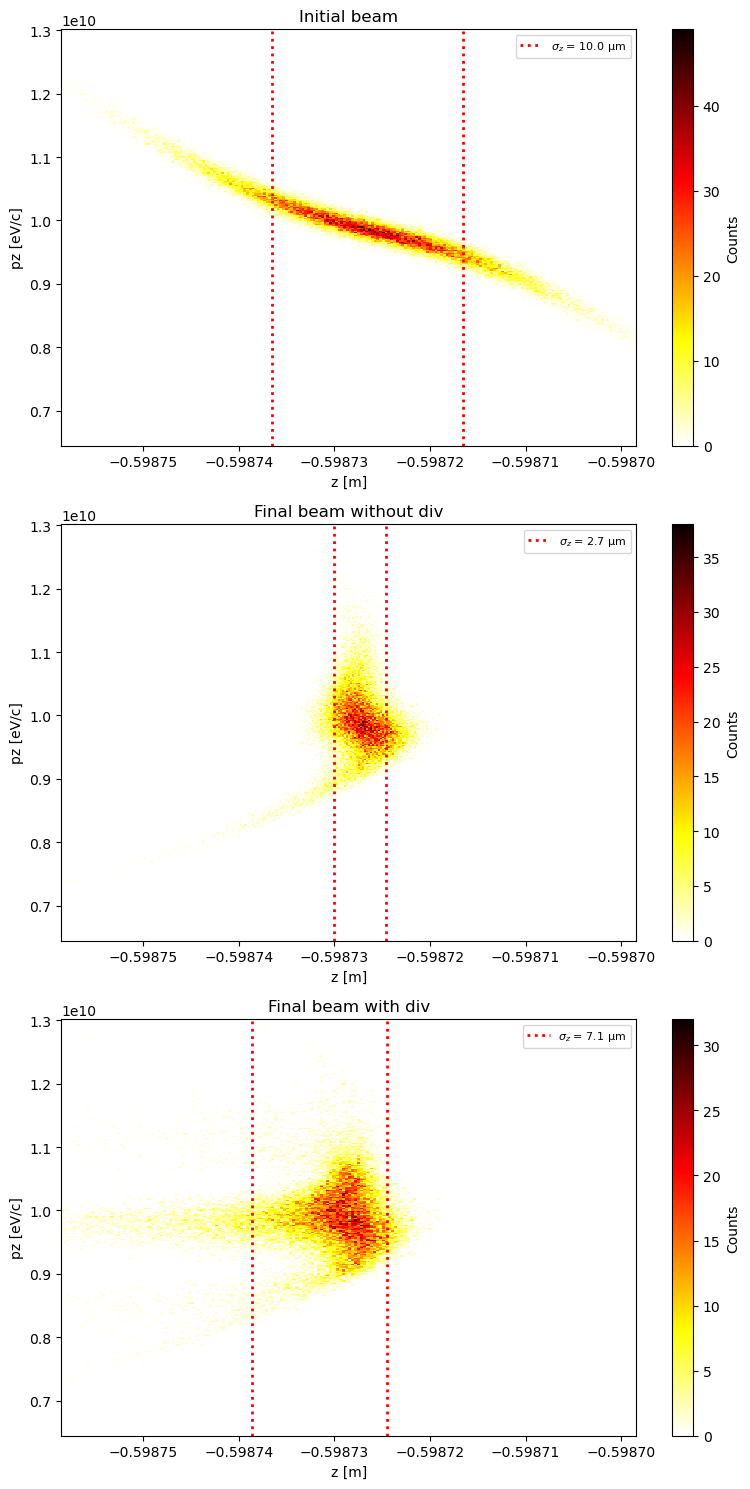

In [92]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharey=True)

plots = [
    (z_plasma_witness, pz_plasma_witness, "Initial beam", sigma_z_witness),
    (z_transported, pz_transported, "Final beam without div", sigma_z),
    (z_with_div, pz_transported, "Final beam with div", sigma_z_with_div),
]

max_sigma_z = max(sigma_z_witness, sigma_z, sigma_z_with_div)
z_center = np.mean([np.mean(z_plasma_witness), np.mean(z_transported), np.mean(z_with_div)])
z_axis_min = z_center - 3*max_sigma_z
z_axis_max = z_center + 3*max_sigma_z

for ax, (z_data, pz_data, title, sigma) in zip(axes, plots):
    im = ax.hist2d(z_data, pz_data, bins=300, cmap="hot_r")
    z_center_data = np.mean(z_data)
    ax.axvline(z_center_data - sigma, color='red', linestyle=':', linewidth=2, label=f'$\\sigma_z$ = {sigma*1e6:.1f} μm')
    ax.axvline(z_center_data + sigma, color='red', linestyle=':', linewidth=2)
    ax.set_xlim(z_axis_min, z_axis_max)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("pz [eV/c]")
    ax.set_title(title)
    ax.grid(False)
    ax.legend(fontsize=8)
    plt.colorbar(im[3], ax=ax, label="Counts")

axes[0].set_ylabel("pz [eV/c]")
plt.tight_layout()
plt.show()

In [93]:
def manual_half_max_width(counts, bins):
    counts = np.asarray(counts, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if counts.size == 0 or bins.size < 2:
        return np.nan, np.nan, np.nan

    peak_idx = int(np.argmax(counts))
    peak_height = counts[peak_idx]
    if peak_height <= 0:
        return np.nan, np.nan, np.nan

    half_height = 0.5 * peak_height
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    left_x = np.nan
    for idx in range(peak_idx, 0, -1):
        y1, y0 = counts[idx], counts[idx - 1]
        if y0 <= half_height <= y1 or y1 <= half_height <= y0:
            left_x = np.interp(half_height, [y0, y1], [bin_centers[idx - 1], bin_centers[idx]])
            break

    right_x = np.nan
    for idx in range(peak_idx, len(counts) - 1):
        y0, y1 = counts[idx], counts[idx + 1]
        if y0 >= half_height >= y1 or y0 <= half_height <= y1:
            right_x = np.interp(half_height, [y0, y1], [bin_centers[idx], bin_centers[idx + 1]])
            break

    if np.isnan(left_x) or np.isnan(right_x):
        return np.nan, left_x, right_x

    return right_x - left_x, left_x, right_x

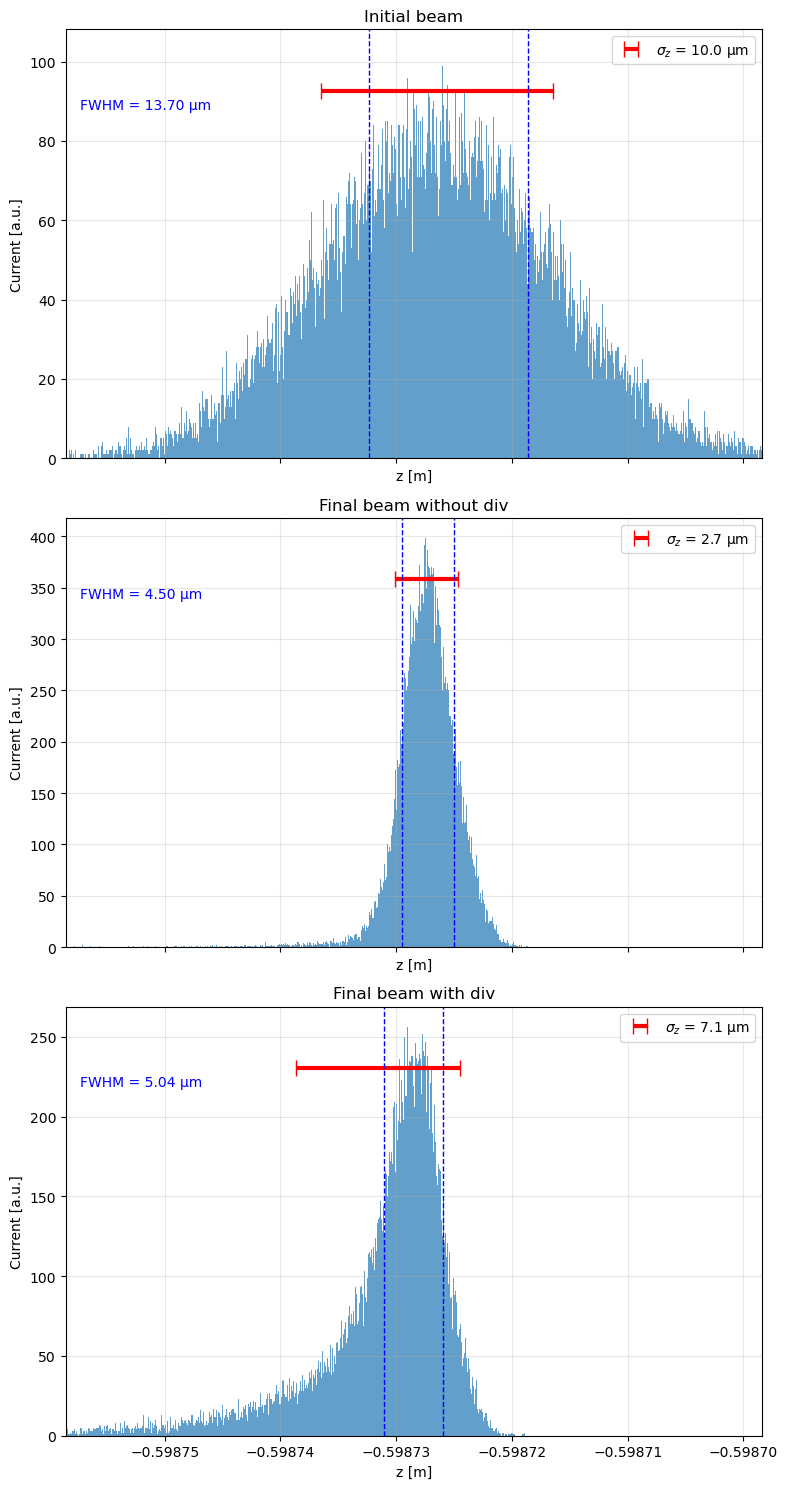

In [94]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=True)

beam_data = [
    (z_plasma_witness, "Initial beam", sigma_z_witness),
    (z_transported, "Final beam without div", sigma_z),
    (z_with_div, "Final beam with div", sigma_z_with_div),
]

z_center = np.mean([np.mean(z_plasma_witness), np.mean(z_transported), np.mean(z_with_div)])
max_sigma_z = max(sigma_z_witness, sigma_z, sigma_z_with_div)
z_axis_min = z_center - 3*max_sigma_z
z_axis_max = z_center + 3*max_sigma_z

for ax, (z_data, title, sigma) in zip(axes, beam_data):

    counts, bins, patches = ax.hist(z_data, bins=1000, range=(z_axis_min, z_axis_max), alpha=0.7)
    z_center_data = np.mean(z_data)
    sigma_bar_y = 0.9 * np.max(counts) if len(counts) else 0
    ax.errorbar(
        z_center_data,
        sigma_bar_y,
        xerr=sigma,
        fmt='none',
        ecolor='red',
        elinewidth=3,
        capsize=6,
        label=f'$\sigma_z$ = {sigma*1e6:.1f} μm',
    )


    if counts.max() > 0:
        peak_idx = np.argmax(counts)
        fwhm, left_x, right_x = manual_half_max_width(counts, bins)
        ax.axvline(left_x, color='blue', linestyle='--', linewidth=1)
        ax.axvline(right_x, color='blue', linestyle='--', linewidth=1)
        ax.text(z_axis_min + 0.02*(z_axis_max - z_axis_min), sigma_bar_y*0.95,
                f'FWHM = {fwhm*1e6:.2f} μm', color='blue', fontsize=10)
    else:
        fwhm = 0
    ax.set_xlim(z_axis_min, z_axis_max)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("Current [a.u.]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [95]:
import os

beam_dir = "beam-transport"
os.makedirs(beam_dir, exist_ok=True)

transported_data_div = {
    'x': transported_data['x'],
    'px': transported_data['px'],
    'y': transported_data['y'],
    'py': transported_data['py'],
    'z': z_with_div - np.mean(z_with_div),
    'pz': transported_data['pz'],
    't': transported_data['t'],
    'weight': transported_data['weight'],
    'id': transported_data['id'],
    'status': transported_data['status'],
    'species': transported_data['species'],
}

transported_beam_div = ParticleGroup(data=transported_data_div)

out_no_div = os.path.join(beam_dir, "transported-beam.h5")
out_div = os.path.join(beam_dir, "transported-beam-div.h5")

for path in (out_no_div, out_div):
    if os.path.exists(path):
        os.remove(path)

transported_beam.write(out_no_div)
transported_beam_div.write(out_div)

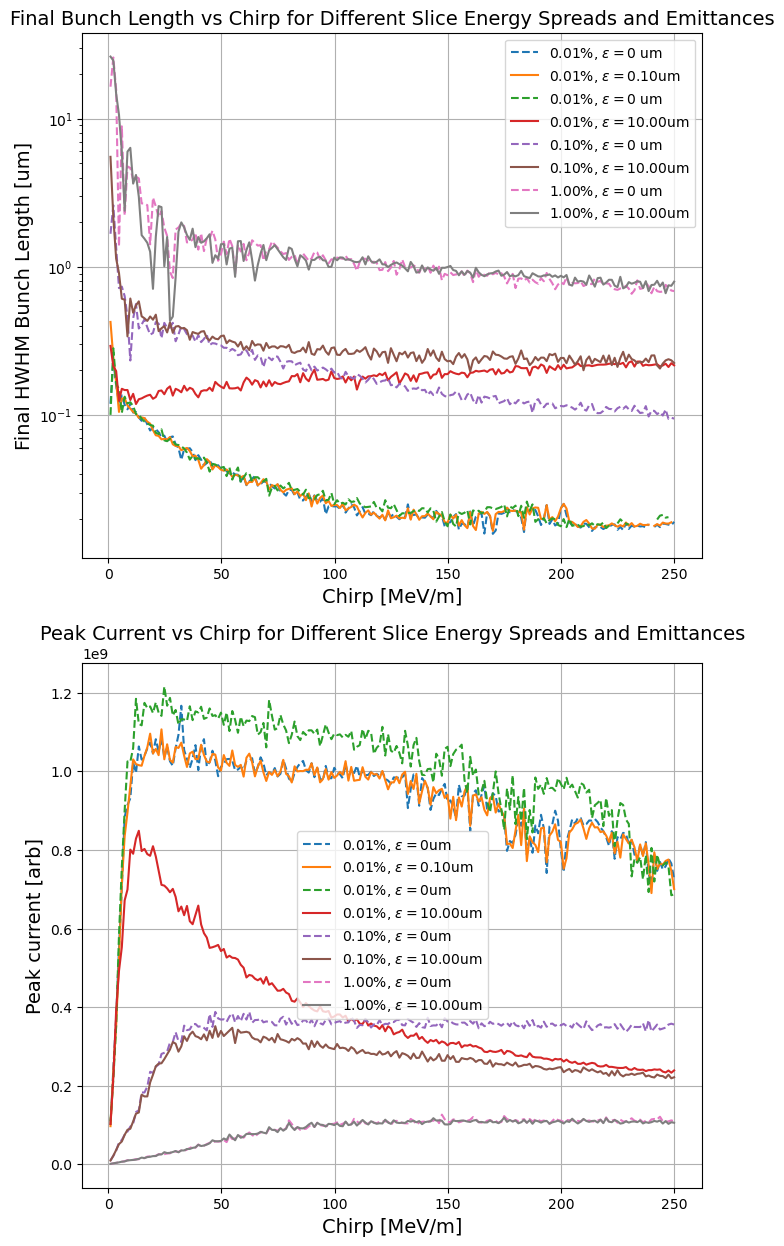

In [96]:
eps_vals = [0.1e-6, 10e-6]
sigma_delta_vals = np.array([0.01, 0.1, 1.0])/100
h_vals = np.linspace(1, 250, 200)*1e6*1e6 # chirp, eV/m
fig, ax = plt.subplots(2, 1, figsize=(8,15))
for eps in eps_vals :
    for sigma_delta in sigma_delta_vals :
        z0 = 0 #m
        beta = 0.1 #m
        energy = 1e10 #eV
        energy_spread = sigma_delta*energy
        total_charge = 5e-10
        gamma0 = energy/(m_e*c**2/e)
        eps_n = eps #m
        eps_g = eps_n / gamma0

        sig_x = np.sqrt(beta*eps_g)
        sig_y = np.sqrt(beta*eps_g)
        sigma_tx = sig_x/beta
        sigma_ty = sig_y/beta

        sig_z = 10.0e-6

        #n_emit_w = 10.0e-6

        n_physical_particles = total_charge/e 
        n_macroparticles = int(1e5)
        w = e*np.ones(n_macroparticles)*n_physical_particles/n_macroparticles
        id = np.arange(0, n_macroparticles, 1)


        x = np.random.normal(loc = 0.0, scale = sig_x, size = n_macroparticles)
        y = np.random.normal(loc = 0.0, scale = sig_y, size = n_macroparticles)
        z = np.random.normal(loc = z0, scale = sig_z, size = n_macroparticles)

        theta_x = np.random.normal(loc=0.0, scale = sigma_tx, size = n_macroparticles)
        theta_y = np.random.normal(loc=0.0, scale = sigma_ty, size = n_macroparticles)

        # Momentum in eV/c units (for ultra-relativistic particles, p ≈ E)




        sig_vals = []
        sig_vals_div = []

        hwhm_vals = []
        hwhm_vals_div = []

        peak_current_vals = []
        peak_current_vals_div = []
        for h_ini in h_vals:

            uz =  h_ini*z + np.random.normal(loc=energy, scale = energy_spread, size = n_macroparticles)

            ux = uz*np.tan(theta_x)
            uy = uz*np.tan(theta_y)

            t = z/c



            data = {'x' : x, 
                    'px' : ux,
                    'y' : y,
                    'py' : uy,
                    'z' : z, 
                    'pz' : uz, 
                    't' : t,
                    'weight' : w,
                    'id' : id,
                    'status' : 1,
                    'species' : 'electron'}

            P0 = ParticleGroup(data = data )

            plasma_beam_witness = P0
            z_plasma_witness = -plasma_beam_witness.t*c
            pz_plasma_witness = plasma_beam_witness.pz
            x_plasma_witness = plasma_beam_witness.x
            a, b = np.polyfit(z_plasma_witness, pz_plasma_witness, 1)
            h = a # chirp, eV/m

            E_mean = energy
            gamma = np.mean(plasma_beam_witness.gamma)
            delta = (plasma_beam_witness.pz - E_mean)/E_mean
            xp = plasma_beam_witness.px/plasma_beam_witness.pz
            yp = plasma_beam_witness.py/plasma_beam_witness.pz

            transverse_phase_space = M4 @ np.array([plasma_beam_witness.x, xp, plasma_beam_witness.y, yp])

            h_norm = h/E_mean


            R_56 = -1/h_norm

            T_566 = -1.5*R_56
            z_transported = z_plasma_witness + R_56*delta + T_566*delta**2 

            z_with_div = z_plasma_witness + R_56*delta + T_566*delta**2 + T_522*xp**2 + T_544*yp**2



            sigma_z_witness = np.std(z_plasma_witness)
            sigma_z = np.std(z_transported)
            sigma_z_with_div = np.std(z_with_div)

            
            # Create histogram of transported z positions
            bin_number = 4500
            counts, bins = np.histogram(z_transported, bins=bin_number)
            
            fwhm = manual_half_max_width(counts, bins)[0]
            hwhm = fwhm/2
            counts_div, bins_div = np.histogram(z_with_div, bins=bin_number)
            fwhm_div = manual_half_max_width(counts_div, bins_div)[0]
            hwhm_div = fwhm_div/2
            sig_vals.append(sigma_z)
            sig_vals_div.append(sigma_z_with_div)
            hwhm_vals.append(hwhm)
            hwhm_vals_div.append(hwhm_div)

            peak_current_vals.append(np.max(counts)/sigma_z)
            peak_current_vals_div.append(np.max(counts_div)/sigma_z_with_div)

        if (sigma_delta == 0.01/100 and eps == 0.1e-6) or (sigma_delta == 0.01/100 and eps == 10e-6) or (sigma_delta == 0.1/100 and eps == 10e-6) or (sigma_delta == 1/100 and eps == 10e-6):
            ax[0].semilogy(h_vals*1e-12, np.array(hwhm_vals)*1e6, "--", label=f'{100*sigma_delta:.2f}%, $\\epsilon = 0$ um')
            ax[0].semilogy(h_vals*1e-12, np.array(hwhm_vals_div)*1e6, "-", label=f'{100*sigma_delta:.2f}%, $\\epsilon=${eps*1e6:.2f}um')
            ax[1].plot(h_vals*1e-12, np.array(peak_current_vals), "--", label=f'{100*sigma_delta:.2f}%, $\\epsilon = 0$um')
            ax[1].plot(h_vals*1e-12, np.array(peak_current_vals_div), "-", label=f'{100*sigma_delta:.2f}%, $\\epsilon=${eps*1e6:.2f}um')

ax[0].set_xlabel('Chirp [MeV/m]', fontsize=14)
ax[0].set_ylabel('Final HWHM Bunch Length [um]', fontsize=14)
ax[0].set_title('Final Bunch Length vs Chirp for Different Slice Energy Spreads and Emittances', fontsize=14)
ax[0].grid()
ax[0].legend()

ax[1].set_xlabel('Chirp [MeV/m]', fontsize=14)
ax[1].set_ylabel('Peak current [arb]', fontsize=14)
ax[1].set_title('Peak Current vs Chirp for Different Slice Energy Spreads and Emittances', fontsize=14)
ax[1].grid()
ax[1].legend()

plt.show()

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


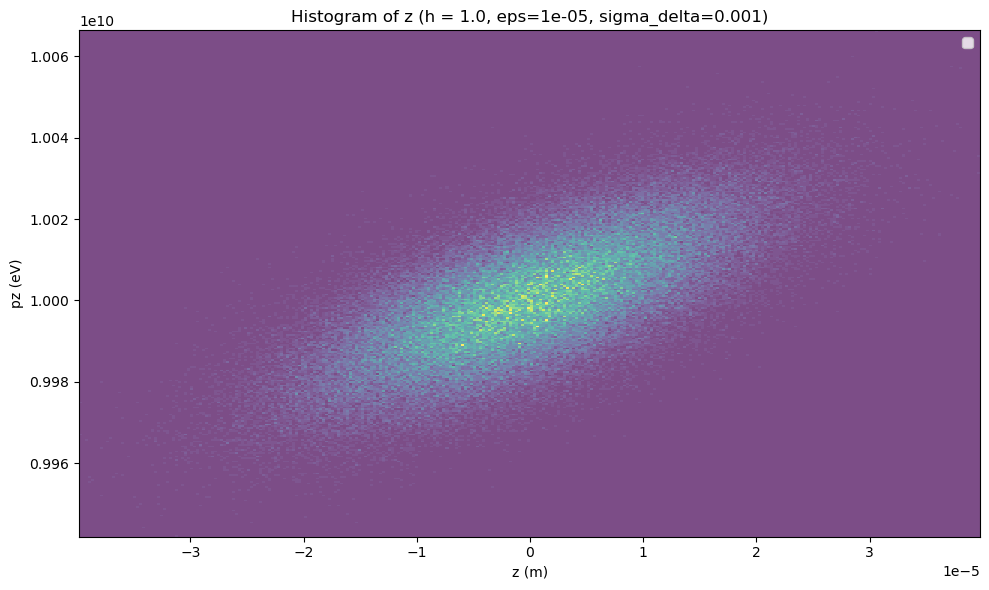

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


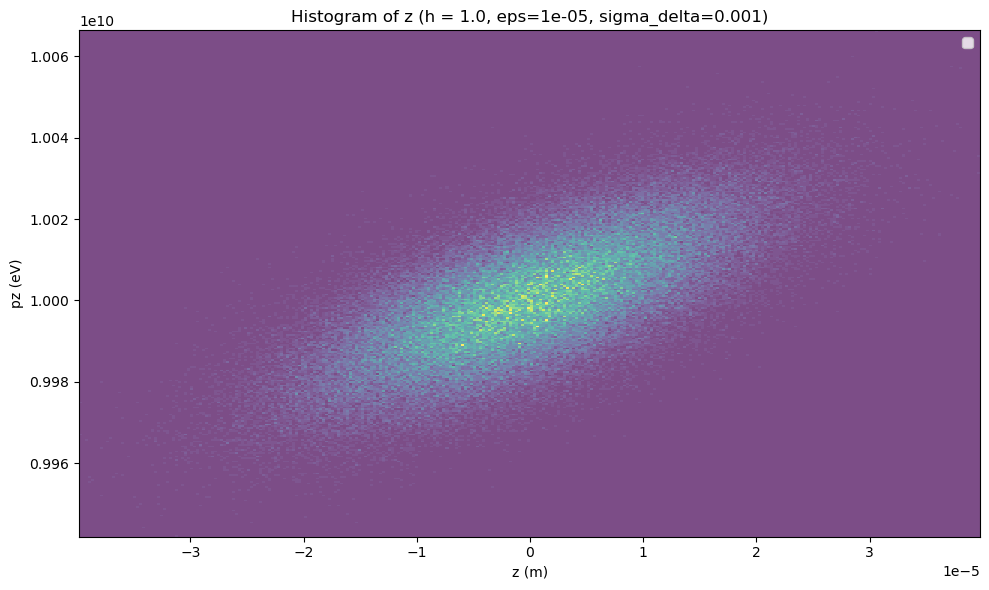

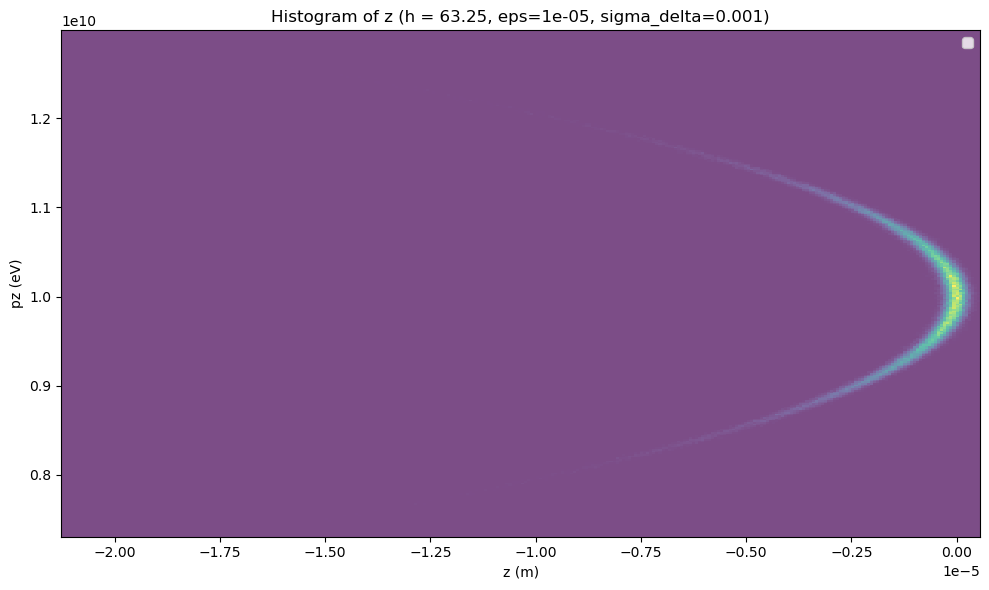

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


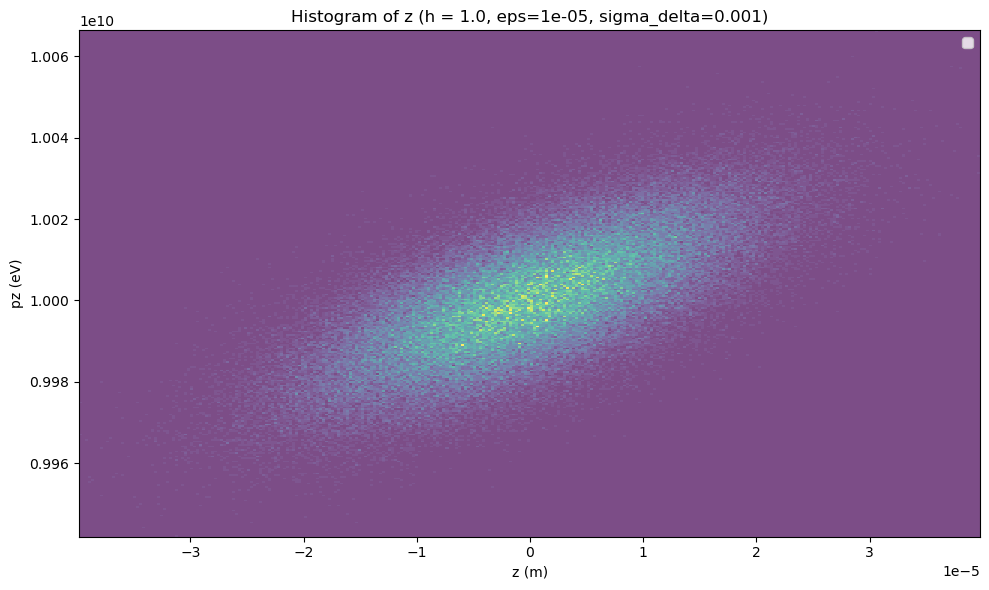

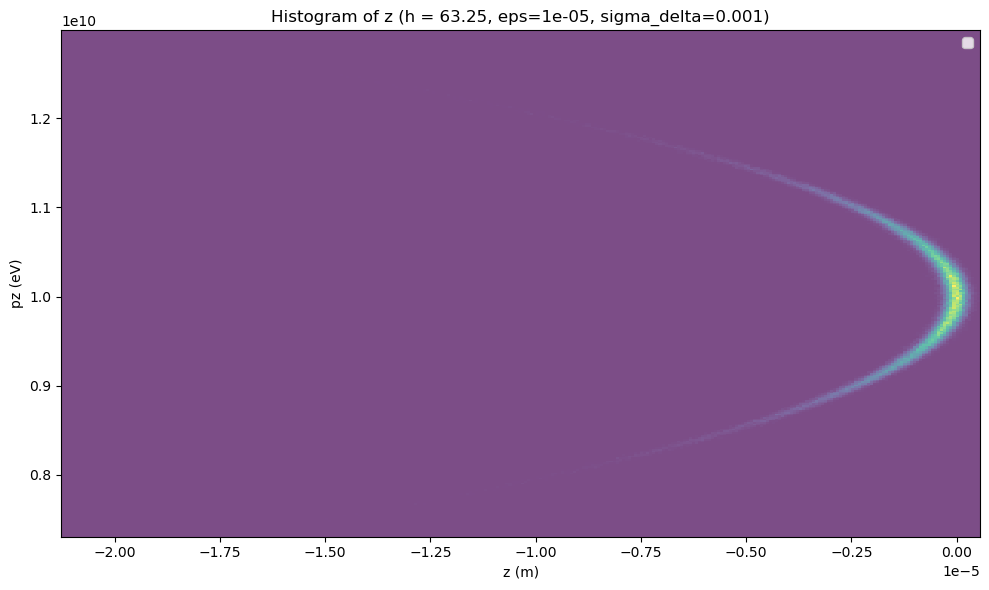

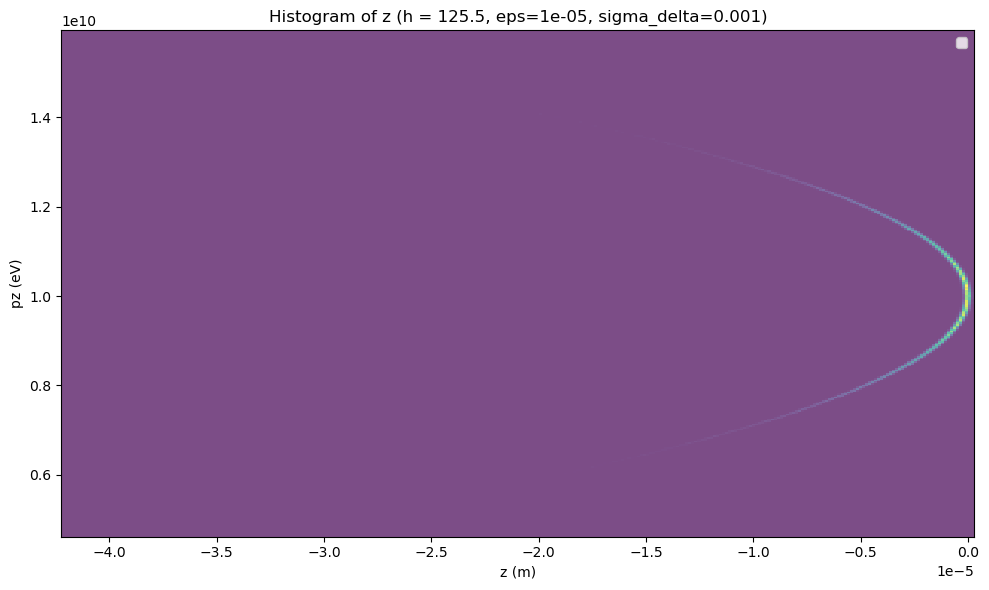

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


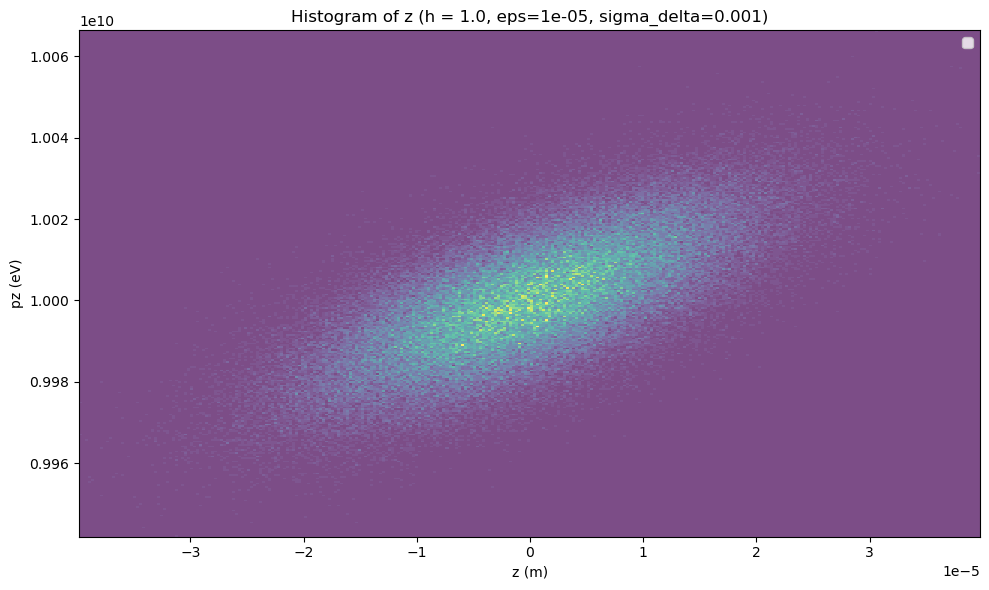

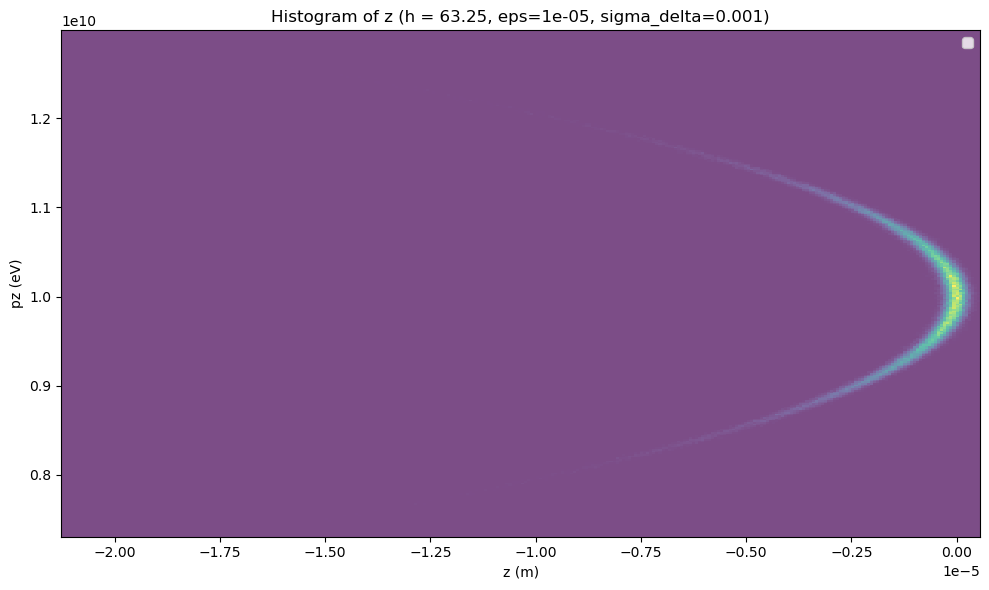

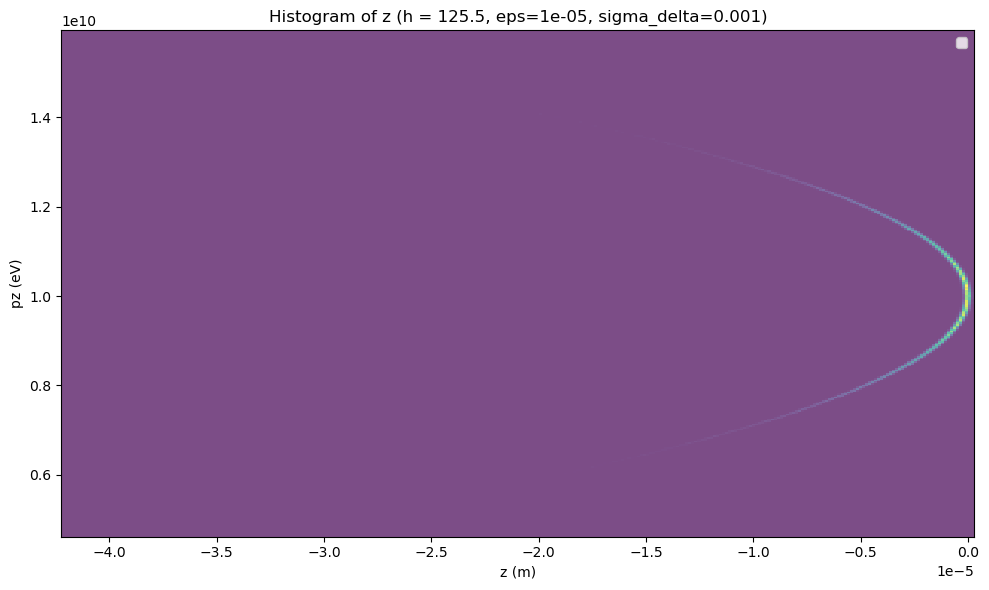

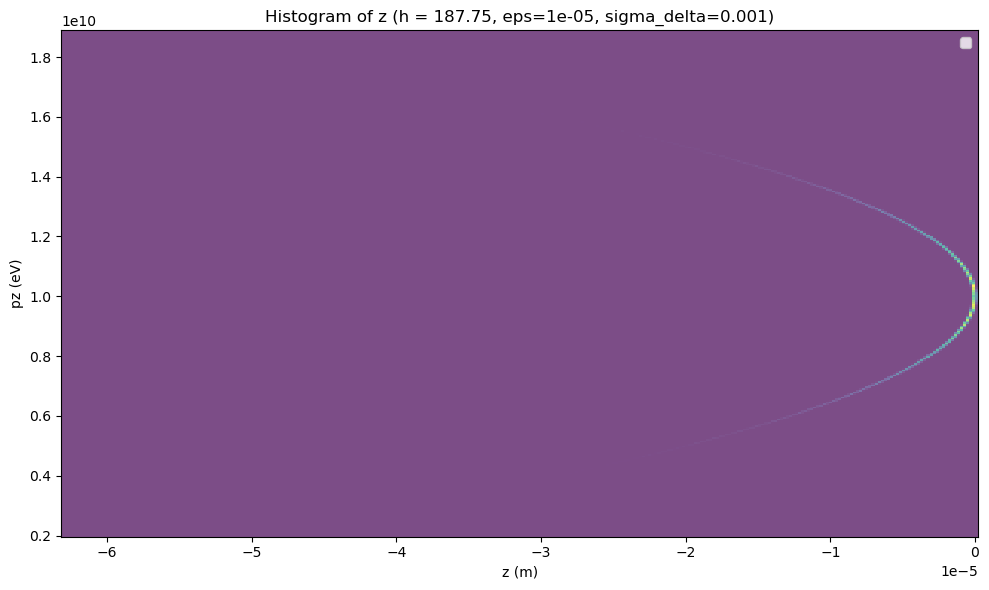

/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/rz/36vv3w1n5t71f3m4k3qv8pr00000gn/T/ipykernel_5874/2623181525.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


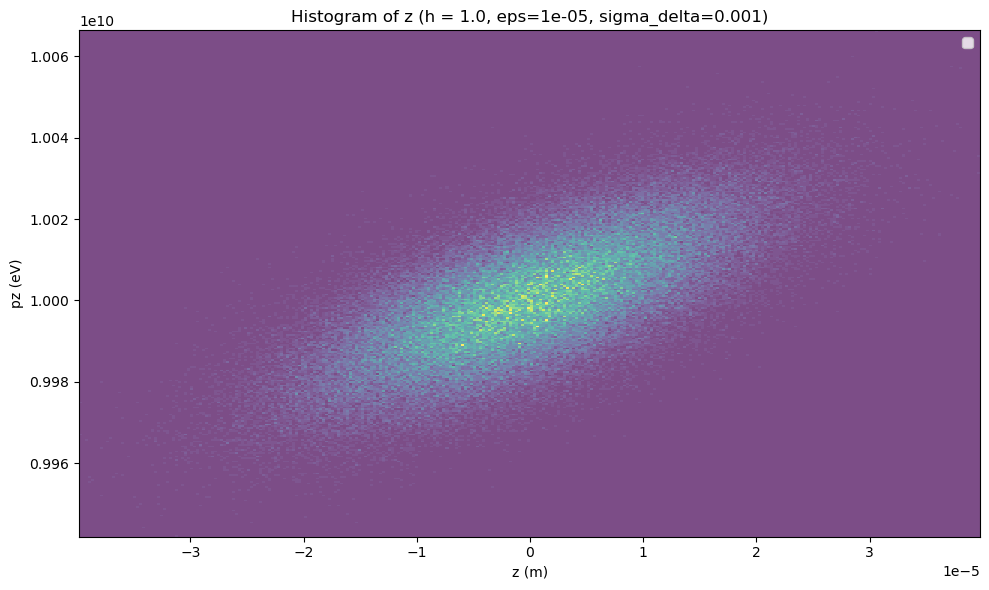

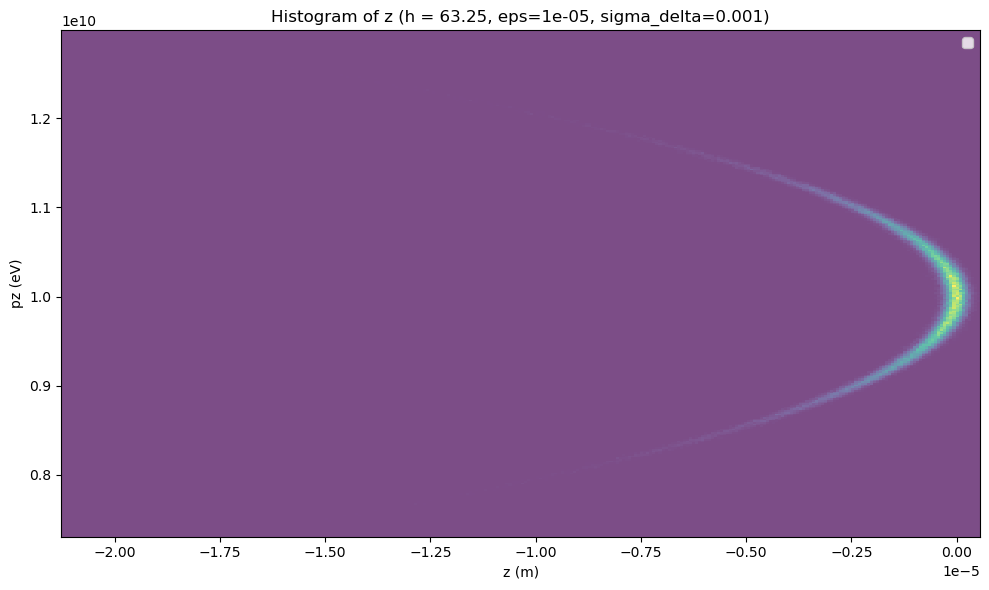

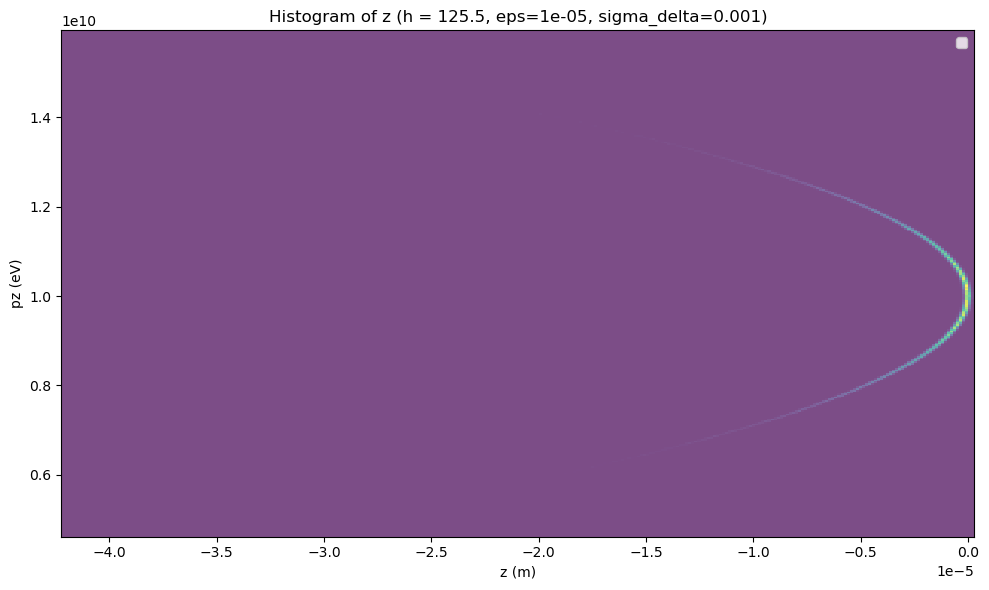

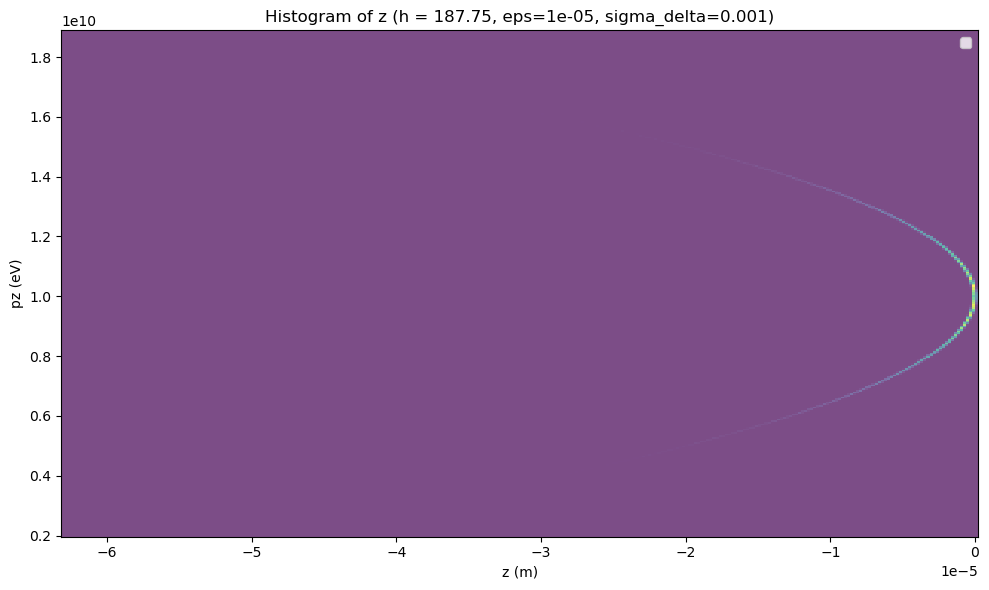

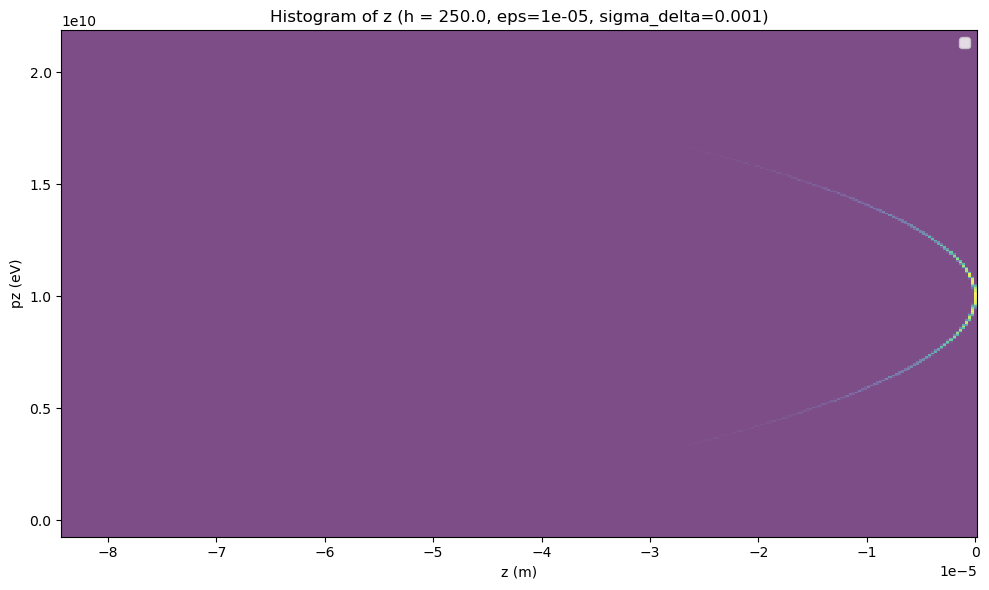

In [97]:
plt.close('all')
eps_vals = [10e-6]
sigma_delta_vals = np.array([0.1])/100
h_vals = np.linspace(1, 250, 5)*1e6*1e6 # chirp, eV/m
for eps in eps_vals :
    for sigma_delta in sigma_delta_vals :
        z0 = 0 #m
        beta = 0.1 #m
        energy = 1e10 #eV
        energy_spread = sigma_delta*energy
        total_charge = 5e-10
        gamma0 = energy/(m_e*c**2/e)
        eps_n = eps #m
        eps_g = eps_n / gamma0

        sig_x = np.sqrt(beta*eps_g)
        sig_y = np.sqrt(beta*eps_g)
        sigma_tx = sig_x/beta
        sigma_ty = sig_y/beta

        sig_z = 10.0e-6

        #n_emit_w = 10.0e-6

        n_physical_particles = total_charge/e 
        n_macroparticles = int(1e5)
        w = e*np.ones(n_macroparticles)*n_physical_particles/n_macroparticles
        id = np.arange(0, n_macroparticles, 1)


        x = np.random.normal(loc = 0.0, scale = sig_x, size = n_macroparticles)
        y = np.random.normal(loc = 0.0, scale = sig_y, size = n_macroparticles)
        z = np.random.normal(loc = z0, scale = sig_z, size = n_macroparticles)

        theta_x = np.random.normal(loc=0.0, scale = sigma_tx, size = n_macroparticles)
        theta_y = np.random.normal(loc=0.0, scale = sigma_ty, size = n_macroparticles)

        # Momentum in eV/c units (for ultra-relativistic particles, p ≈ E)




        sig_vals = []
        sig_vals_div = []

        fwhm_vals = []
        fwhm_vals_div = []

        peak_current_vals = []
        peak_current_vals_div = []
        for h_ini in h_vals:

            uz =  h_ini*z + np.random.normal(loc=energy, scale = energy_spread, size = n_macroparticles)

            ux = uz*np.tan(theta_x)
            uy = uz*np.tan(theta_y)

            t = z/c



            data = {'x' : x, 
                    'px' : ux,
                    'y' : y,
                    'py' : uy,
                    'z' : z, 
                    'pz' : uz, 
                    't' : t,
                    'weight' : w,
                    'id' : id,
                    'status' : 1,
                    'species' : 'electron'}

            P0 = ParticleGroup(data = data )

            plasma_beam_witness = P0
            z_plasma_witness = -plasma_beam_witness.t*c
            pz_plasma_witness = plasma_beam_witness.pz
            x_plasma_witness = plasma_beam_witness.x
            a, b = np.polyfit(z_plasma_witness, pz_plasma_witness, 1)
            h = a # chirp, eV/m

            E_mean = energy
            gamma = np.mean(plasma_beam_witness.gamma)
            delta = (plasma_beam_witness.pz - E_mean)/E_mean
            xp = plasma_beam_witness.px/plasma_beam_witness.pz
            yp = plasma_beam_witness.py/plasma_beam_witness.pz

            transverse_phase_space = M4 @ np.array([plasma_beam_witness.x, xp, plasma_beam_witness.y, yp])

            h_norm = h/E_mean


            R_56 = -1/h_norm

            T_566 = -1.5*R_56
            z_transported = z_plasma_witness + R_56*delta + T_566*delta**2 

            z_with_div = z_plasma_witness + R_56*delta + T_566*delta**2 + T_522*xp**2 + T_544*yp**2

            transported_data = {
            'x': transverse_phase_space[0],
            'px': transverse_phase_space[1]*plasma_beam_witness.pz,
            'y': transverse_phase_space[2],
            'py': transverse_phase_space[3]*plasma_beam_witness.pz,
            'z': z_transported,
            'pz': plasma_beam_witness.pz,
            't': plasma_beam_witness.t,
            'weight': plasma_beam_witness.weight,
            'id': plasma_beam_witness.id,
            'status': plasma_beam_witness.status,
            'species': 'electron',
            }

            transported_beam = ParticleGroup(data=transported_data)

            sigma_z_witness = np.std(z_plasma_witness)
            sigma_z = np.std(z)
            sigma_z_with_div = np.std(z_with_div)
        
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.hist2d(transported_beam.z, transported_beam.pz, bins=300, alpha=0.7, label='z without divergence')
            ax.set_xlabel('z (m)')
            ax.set_ylabel('pz (eV)')
            ax.set_title(f'Histogram of z (h = {h_ini*1e-12}, eps={eps}, sigma_delta={sigma_delta})')
            ax.legend()
            plt.tight_layout()
            plt.show()



In [98]:
beam = h5py.File("beam-transport/transported-beam-div.h5", "r")

list(beam.keys())





['particles']